# 7. Bayesian Modeling of Female Participation in UTMB Races

This notebook extends the previous Bayesian workflow from finish-time modelling to **female participation modelling**.

The response is the number of women taking part in a race:

$$
Y_i = \text{N Women}_i
$$

However, this count is not meaningful without the total number of participants. A race with 800 participants will naturally have more women than a race with 80 participants, even if the female participation rate is identical. Therefore, we model the number of women **conditional on the total race size**:

$$
Y_i \mid N_i, p_i
$$

where:

- $Y_i$ is the number of women in race $i$,
- $N_i$ is the total number of participants in race $i$,
- $p_i$ is the latent female participation probability/share.

We compare two Bayesian count models:

| Model | Likelihood | Purpose |
|---|---|---|
| Model 7A | Binomial logistic regression | Baseline bounded count model |
| Model 7B | Beta-Binomial logistic regression | Robust/overdispersed count model |

The second model is expected to be more realistic when female participation varies more between races than a simple Binomial model allows.

## 7.1 Research question

**How do race characteristics and time trends influence female participation in UTMB races?**

Predictors used in this notebook:

| Predictor | Dataset column / transformation | Reason |
|---|---|---|
| Distance | `log(Distance)` standardized | longer races may attract a different participant structure |
| Elevation gain | `log(Elevation Gain + 1)` standardized | route difficulty |
| Steepness | `log1p(Elevation Gain / Distance)` standardized | difficulty per kilometre |
| Altitude | `log1p(Elevation)` standardized | environmental/altitude effect |
| Longitude | `Longitude` standardized | geographic effect |
| Latitude | `Latitude` standardized | geographic effect; included because the raw dataset contains both coordinates |
| Year | `Year` standardized | important trend variable over time |

The target variable is `N Women`, and the exposure/trial count is `N Participants`.

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10

RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

PROJECT_ROOT = Path(".")
FIG_DIR = PROJECT_ROOT / "figures_female_participation"
FIG_DIR.mkdir(exist_ok=True)

## 7.2 Load data

The current `utmb_processed.csv` created in notebook 01 may not contain `N Women`, `Longitude`, and `Latitude`, because the original mean-time workflow selected only the variables needed for finish-time modelling.

Therefore, this notebook first tries to load the raw Kaggle file `utmb-race-data-sheet.csv`. If it is not available locally, it uses `kagglehub` to download the dataset.

In [2]:
def load_raw_utmb_data() -> pd.DataFrame:
    """Load the raw UTMB dataset from a local file, KaggleHub cache, or KaggleHub download."""
    candidate_paths = [
        PROJECT_ROOT / "utmb-race-data-sheet.csv",
        Path.home() / ".cache" / "kagglehub" / "datasets" / "mgpoirot" / "utmb-world-race-daa" / "versions" / "1" / "utmb-race-data-sheet.csv",
    ]

    for path in candidate_paths:
        if path.exists():
            print(f"Loading raw data from: {path}")
            return pd.read_csv(path, low_memory=False)

    print("Raw file not found locally. Trying KaggleHub download...")
    try:
        import kagglehub
        data_path = Path(kagglehub.dataset_download("mgpoirot/utmb-world-race-daa"))
        csv_path = data_path / "utmb-race-data-sheet.csv"
        print(f"Loading raw data from: {csv_path}")
        return pd.read_csv(csv_path, low_memory=False)
    except Exception as exc:
        raise FileNotFoundError(
            "Could not load the raw UTMB dataset. Put 'utmb-race-data-sheet.csv' in the project root "
            "or install/configure kagglehub."
        ) from exc


df_raw = load_raw_utmb_data()
print(f"Raw dataset shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

Raw file not found locally. Trying KaggleHub download...
Loading raw data from: /root/.cache/kagglehub/datasets/mgpoirot/utmb-world-race-daa/versions/6/utmb-race-data-sheet.csv
Raw dataset shape: 38,460 rows x 22 columns


,Race UID,Year,Day,Race Title,N Participants,Race Category,Distance,Elevation Gain,Mean Finish Time,Winning Time,...,N Women,N Countries,Raw Location,Administrative Level,Continent,Country,Elevation,Longitude,Latitude,Elevation Variance
0,10001,2017,309,Caravaca Trail Experience 2017 - Promo,292,-,12.0,400,2.0829,0.9050,...,142,1,Spain,1.0,EU,ES,594.10,-3.749220,40.463667,0.0
1,10003,2017,309,Caravaca Trail Experience 2017 - Master,163,50K,35.2,2030,4.9722,3.1583,...,26,3,Spain,1.0,EU,ES,594.10,-3.749220,40.463667,0.0
2,10003,2018,301,Caravaca Trail Experience 2018 - Master,81,50K,34.5,1630,4.5411,3.3642,...,10,2,Spain,1.0,EU,ES,594.10,-3.749220,40.463667,0.0
3,10003,2019,300,Caravaca Trail Experience 2019 - MASTER,65,50K,34.6,1630,4.5033,3.2142,...,8,2,Spain,1.0,EU,ES,594.10,-3.749220,40.463667,0.0
4,10005,2017,287,The Red Leaves Trail Running Race 2017 - 25KM,53,20K,27.2,1660,6.3384,3.4475,...,20,1,China,1.0,AS,CN,1840.54,104.195397,35.861660,0.0


## 7.3 Data cleaning and feature engineering

The cleaning logic follows the spirit of notebook 01:

- keep the four main UTMB categories: `20K`, `50K`, `100K`, `100M`;
- remove missing and physically inconsistent values;
- keep only rows where `0 <= N Women <= N Participants`;
- apply the same log-transform idea used in the log-time models;
- standardize all predictors used by Stan.

Important naming convention:

- `Elevation Gain` = total uphill metres on the course;
- `Elevation` = altitude above sea level from the raw dataset; in this notebook it is renamed conceptually to **altitude**.

In [3]:
required_cols = [
    "Race Category",
    "Distance",
    "Elevation Gain",
    "N Participants",
    "N Women",
    "Year",
    "Country",
    "Elevation",      # altitude above sea level in the raw dataset
    "Longitude",
    "Latitude",
]

missing = [c for c in required_cols if c not in df_raw.columns]
if missing:
    raise ValueError(f"Missing required columns in raw dataset: {missing}")

df = df_raw[required_cols].copy()

numeric_cols = [
    "Distance", "Elevation Gain", "N Participants", "N Women",
    "Year", "Elevation", "Longitude", "Latitude",
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Before cleaning:")
print(f"  Shape: {df.shape}")
print("  Missing values:")
print(df.isna().sum().to_string())

main_cats = ["20K", "50K", "100K", "100M"]
df = df[df["Race Category"].isin(main_cats)].copy()

df = df.dropna(subset=required_cols)

# Basic consistency checks for count data.
df = df[df["N Participants"] > 0]
df = df[df["N Women"] >= 0]
df = df[df["N Women"] <= df["N Participants"]]

# Same broad physical filters as the finish-time workflow.
df = df[(df["Distance"] > 5) & (df["Distance"] < 300)]
df = df[(df["Elevation Gain"] >= 100) & (df["Elevation Gain"] < 20000)]

# Convert count variables to integer after filtering.
df["n_participants"] = np.rint(df["N Participants"]).astype(int)
df["n_women"] = np.rint(df["N Women"]).astype(int)
df = df[df["n_women"] <= df["n_participants"]]

df["female_share"] = df["n_women"] / df["n_participants"]

print("\nAfter cleaning:")
print(f"  Shape: {df.shape}")
print("\nCategory distribution:")
print(df["Race Category"].value_counts().to_string())
print("\nFemale share summary:")
print(df["female_share"].describe().to_string())

Before cleaning:
  Shape: (38460, 10)
  Missing values:
Race Category     0
Distance          0
Elevation Gain    0
N Participants    0
N Women           0
Year              0
Country           7
Elevation         0
Longitude         0
Latitude          0

After cleaning:
  Shape: (36479, 13)

Category distribution:
Race Category
50K     15488
20K     10749
100K     7395
100M     2847

Female share summary:
count    36479.000000
mean         0.229724
std          0.131077
min          0.000000
25%          0.134516
50%          0.208791
75%          0.305556
max          1.000000


In [4]:
def standardise(s: pd.Series) -> pd.Series:
    """Standardize a pandas Series. If the variable has zero variance, return zeros."""
    s = s.astype(float)
    sd = s.std()
    if sd == 0 or np.isnan(sd):
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / sd

# Log-transform physical variables, following the log-time workflow.
df["log_distance"] = np.log(df["Distance"])
df["log_elevation_gain"] = np.log1p(df["Elevation Gain"])
df["steepness"] = df["Elevation Gain"] / df["Distance"]
df["log_steepness"] = np.log1p(df["steepness"])

# The raw column 'Elevation' is altitude above sea level. Clip at zero before log1p
# to avoid issues if a few locations are slightly below sea level.
df["altitude"] = df["Elevation"].clip(lower=0)
df["log_altitude"] = np.log1p(df["altitude"])

# Standardized predictors used in Stan.
df["distance_log_std"] = standardise(df["log_distance"])
df["elevation_gain_log_std"] = standardise(df["log_elevation_gain"])
df["steepness_std"] = standardise(df["log_steepness"])
df["altitude_std"] = standardise(df["log_altitude"])
df["longitude_std"] = standardise(df["Longitude"])
df["latitude_std"] = standardise(df["Latitude"])
df["year_std"] = standardise(df["Year"])

model_cols = [
    "Race Category", "Country", "Year",
    "Distance", "Elevation Gain", "steepness", "altitude", "Longitude", "Latitude",
    "n_participants", "n_women", "female_share",
    "distance_log_std", "elevation_gain_log_std", "steepness_std", "altitude_std",
    "longitude_std", "latitude_std", "year_std",
]

df_model = df[model_cols].copy()
df_model.to_csv("utmb_female_participation_processed.csv", index=False)

print("Standardized predictor checks:")
for c in ["distance_log_std", "elevation_gain_log_std", "steepness_std", "altitude_std", "longitude_std", "latitude_std", "year_std"]:
    print(f"  {c:24s} mean={df_model[c].mean(): .4f}, std={df_model[c].std(): .4f}")

print("\nSaved: utmb_female_participation_processed.csv")
df_model.head()

Standardized predictor checks:
  distance_log_std         mean=-0.0000, std= 1.0000
  elevation_gain_log_std   mean= 0.0000, std= 1.0000
  steepness_std            mean=-0.0000, std= 1.0000
  altitude_std             mean=-0.0000, std= 1.0000
  longitude_std            mean=-0.0000, std= 1.0000
  latitude_std             mean=-0.0000, std= 1.0000
  year_std                 mean= 0.0000, std= 1.0000

Saved: utmb_female_participation_processed.csv


,Race Category,Country,Year,Distance,Elevation Gain,steepness,altitude,Longitude,Latitude,n_participants,n_women,female_share,distance_log_std,elevation_gain_log_std,steepness_std,altitude_std,longitude_std,latitude_std,year_std
1,50K,ES,2017,35.2,2030,57.670455,594.10,-3.749220,40.463667,163,26,0.159509,-0.550926,0.039008,0.717114,0.554078,-0.156239,0.249022,-0.854108
2,50K,ES,2018,34.5,1630,47.246377,594.10,-3.749220,40.463667,81,10,0.123457,-0.583069,-0.263469,0.328115,0.554078,-0.156239,0.249022,-0.486578
3,50K,ES,2019,34.6,1630,47.109827,594.10,-3.749220,40.463667,65,8,0.123077,-0.578438,-0.263469,0.322479,0.554078,-0.156239,0.249022,-0.119048
4,20K,CN,2017,27.2,1660,61.029412,1840.54,104.195397,35.861660,53,20,0.377358,-0.963510,-0.238333,0.827823,1.275096,1.476193,0.045814,-0.854108
5,20K,CN,2018,28.1,1750,62.277580,1840.54,104.195397,35.861660,44,13,0.295455,-0.911419,-0.165564,0.867440,1.275096,1.476193,0.045814,-0.486578


### Results interpretation — data preparation

The cleaned dataset contains **36,479 races** after filtering to the main UTMB race categories (`20K`, `50K`, `100K`, `100M`) and removing invalid or incomplete rows. This is almost the full usable dataset, so the subsequent analysis is based on a broad race-level sample rather than on a small selected subset.

The target is not modelled as an unconstrained continuous variable. Instead, the notebook models `n_women` conditionally on `n_participants`, which is the appropriate formulation for a count bounded between 0 and the total number of runners in a race. The observed race-level female share has mean approximately **0.230**, median approximately **0.209**, and a wide range from **0** to **1**, indicating substantial heterogeneity between races.

All continuous predictors were standardized successfully, which makes the regression coefficients comparable: each coefficient describes the effect of a one-standard-deviation change in the corresponding predictor on the log-odds of female participation.

## 7.4 Exploratory data analysis

Before modelling, we inspect:

1. distribution of `N Women`;
2. distribution of female share;
3. relationship between women count and total participants;
4. trend over year;
5. category-level differences.

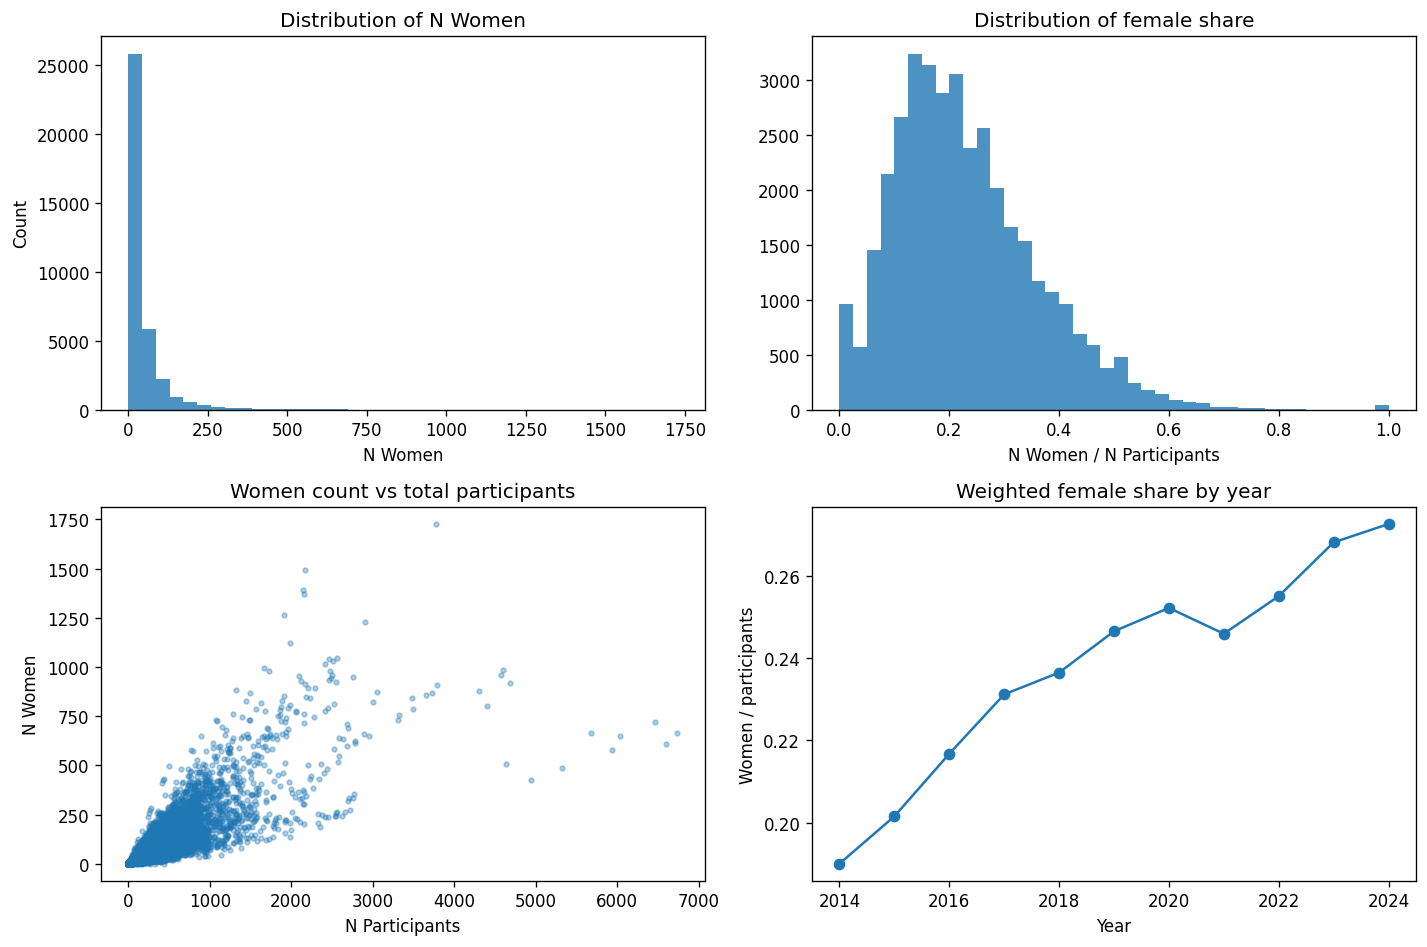

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df_model["n_women"], bins=40, alpha=0.8)
axes[0, 0].set_title("Distribution of N Women")
axes[0, 0].set_xlabel("N Women")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(df_model["female_share"], bins=40, alpha=0.8)
axes[0, 1].set_title("Distribution of female share")
axes[0, 1].set_xlabel("N Women / N Participants")

axes[1, 0].scatter(df_model["n_participants"], df_model["n_women"], s=8, alpha=0.35)
axes[1, 0].set_title("Women count vs total participants")
axes[1, 0].set_xlabel("N Participants")
axes[1, 0].set_ylabel("N Women")

annual_share = (
    df_model.groupby("Year")
    .apply(lambda g: g["n_women"].sum() / g["n_participants"].sum())
    .reset_index(name="weighted_female_share")
)
axes[1, 1].plot(annual_share["Year"], annual_share["weighted_female_share"], marker="o")
axes[1, 1].set_title("Weighted female share by year")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Women / participants")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_fp_01_eda_overview.png", bbox_inches="tight")
plt.show()

In [6]:
category_summary = (
    df_model.groupby("Race Category")
    .agg(
        races=("n_women", "size"),
        total_participants=("n_participants", "sum"),
        total_women=("n_women", "sum"),
        mean_female_share=("female_share", "mean"),
        weighted_female_share=("n_women", lambda s: s.sum() / df_model.loc[s.index, "n_participants"].sum()),
    )
    .sort_index()
)
category_summary

,races,total_participants,total_women,mean_female_share,weighted_female_share
Race Category,,,,,
100K,7395,1079877,184150,0.170390,0.170529
100M,2847,352067,47887,0.146022,0.136017
20K,10749,2491448,773077,0.301451,0.310292
50K,15488,2798121,618330,0.223659,0.220980


### Results interpretation — exploratory analysis

The exploratory analysis shows a clear relationship between race category and female participation. The weighted female share is highest for **20K races** at approximately **31.0%**, then decreases for **50K races** to approximately **22.1%**, for **100K races** to approximately **17.1%**, and reaches the lowest level for **100M races** at approximately **13.6%**.

This pattern strongly suggests that longer and more demanding races tend to have a lower proportion of women. However, category-level summaries alone cannot separate the effects of distance, elevation gain, steepness, geography and year. This motivates the regression model with multiple standardized predictors.

The difference between mean female share and weighted female share is also important: larger races contribute more to the weighted share. Therefore, the model uses `n_participants` directly in the likelihood instead of treating every race-level percentage as equally precise.

## 7.5 Model specification

### Model 7A: Binomial logistic regression

$$
Y_i \sim \text{Binomial}(N_i, p_i)
$$

$$
\text{logit}(p_i) = \alpha
+ \beta_{dist}x_{dist,i}
+ \beta_{elev}x_{elev,i}
+ \beta_{steep}x_{steep,i}
+ \beta_{alt}x_{alt,i}
+ \beta_{lon}x_{lon,i}
+ \beta_{lat}x_{lat,i}
+ \beta_{year}x_{year,i}
$$

### Model 7B: Beta-Binomial logistic regression

$$
Y_i \sim \text{Beta-Binomial}(N_i, p_i\phi, (1-p_i)\phi)
$$

The mean structure is identical, but the Beta-Binomial model adds overdispersion through $\phi$.

Interpretation of $\phi$:

- large $\phi$ → similar to Binomial;
- small $\phi$ → stronger race-to-race variability beyond the Binomial assumption.

## 7.6 Prior rationale

All predictors are standardized, so each coefficient describes the change in log-odds of female participation for a one-standard-deviation increase in the predictor.

| Parameter | Prior | Rationale |
|---|---|---|
| $\alpha$ | $Normal(logit(0.25), 1)$ | typical female share around 25%, but deliberately wide |
| $\beta_{dist}$ | $Normal(-0.10, 0.35)$ | longer races may slightly reduce female share; weak prior |
| $\beta_{elev}$ | $Normal(-0.05, 0.35)$ | harder elevation profile may slightly reduce share; weak prior |
| $\beta_{steep}$ | $Normal(-0.05, 0.35)$ | steepness effect uncertain, weakly negative |
| $\beta_{alt}$ | $Normal(0, 0.25)$ | weak geographic/environmental prior |
| $\beta_{lon}$ | $Normal(0, 0.30)$ | weak spatial prior |
| $\beta_{lat}$ | $Normal(0, 0.30)$ | weak spatial prior |
| $\beta_{year}$ | $Normal(0.20, 0.25)$ | positive trend over time is plausible but not forced |
| $\log(\phi)$ | $Normal(log(50), 1)$ | Beta-Binomial overdispersion; high values approximate Binomial |

The prior on $\alpha$ gives broad prior mass over plausible female participation rates. The regression priors are weak enough to allow the data to dominate.

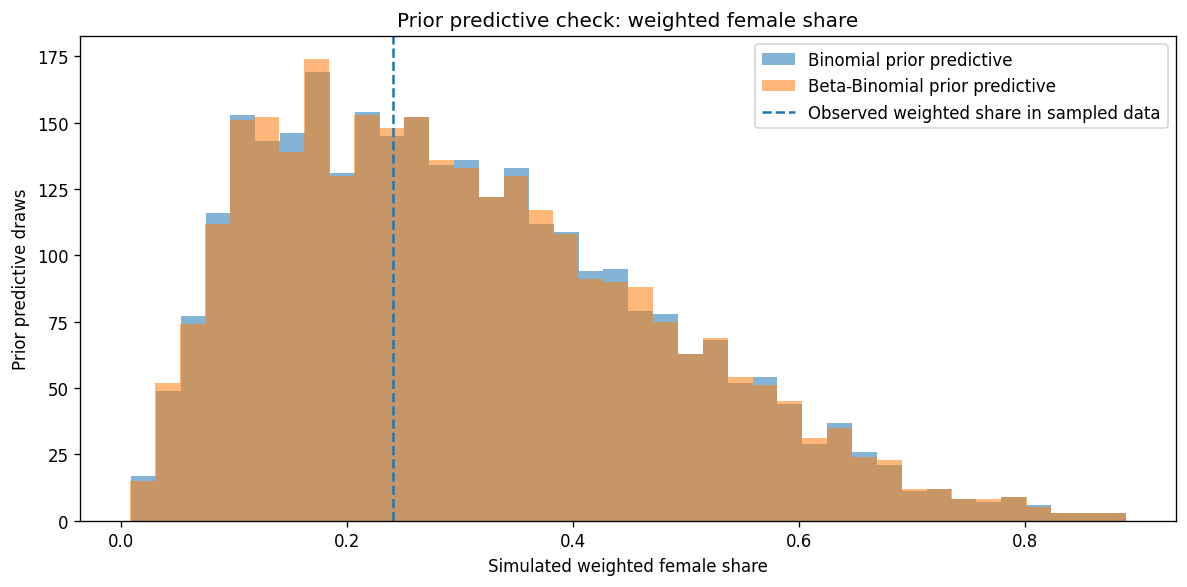

,quantity,mean,q05,q95
0,Binomial prior weighted share,0.304974,0.076862,0.621709
1,Beta-Binomial prior weighted share,0.305003,0.076371,0.620785
2,Observed weighted share,0.240801,NaN,NaN


In [7]:
def inv_logit(x):
    return 1 / (1 + np.exp(-x))

S = 3000
M = min(1000, len(df_model))
prior_df = df_model.sample(M, random_state=RANDOM_SEED).reset_index(drop=True)
X_prior = prior_df[[
    "distance_log_std", "elevation_gain_log_std", "steepness_std", "altitude_std",
    "longitude_std", "latitude_std", "year_std",
]].to_numpy()
N_part_prior = prior_df["n_participants"].to_numpy().astype(int)

alpha = rng.normal(-1.0986122886681098, 1.0, size=S)
beta_dist = rng.normal(-0.10, 0.35, size=S)
beta_elev = rng.normal(-0.05, 0.35, size=S)
beta_steep = rng.normal(-0.05, 0.35, size=S)
beta_alt = rng.normal(0.00, 0.25, size=S)
beta_lon = rng.normal(0.00, 0.30, size=S)
beta_lat = rng.normal(0.00, 0.30, size=S)
beta_year = rng.normal(0.20, 0.25, size=S)

B = np.column_stack([beta_dist, beta_elev, beta_steep, beta_alt, beta_lon, beta_lat, beta_year])
eta_prior = alpha[:, None] + B @ X_prior.T
p_prior = inv_logit(eta_prior)

# Simulate counts under both likelihoods for prior predictive checking.
y_prior_binom = rng.binomial(N_part_prior[None, :], p_prior)

phi = np.exp(rng.normal(np.log(50), 1.0, size=S))
y_prior_betabinom = np.empty_like(y_prior_binom)
for s in range(S):
    a = p_prior[s] * phi[s]
    b = (1 - p_prior[s]) * phi[s]
    p_latent = rng.beta(a, b)
    y_prior_betabinom[s] = rng.binomial(N_part_prior, p_latent)

prior_share_binom = y_prior_binom.sum(axis=1) / N_part_prior.sum()
prior_share_betabinom = y_prior_betabinom.sum(axis=1) / N_part_prior.sum()

observed_weighted_share = prior_df["n_women"].sum() / prior_df["n_participants"].sum()

plt.figure(figsize=(10, 5))
plt.hist(prior_share_binom, bins=40, alpha=0.55, label="Binomial prior predictive")
plt.hist(prior_share_betabinom, bins=40, alpha=0.55, label="Beta-Binomial prior predictive")
plt.axvline(observed_weighted_share, linestyle="--", label="Observed weighted share in sampled data")
plt.title("Prior predictive check: weighted female share")
plt.xlabel("Simulated weighted female share")
plt.ylabel("Prior predictive draws")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_fp_02_prior_predictive_share.png", bbox_inches="tight")
plt.show()

pd.DataFrame({
    "quantity": ["Binomial prior weighted share", "Beta-Binomial prior weighted share", "Observed weighted share"],
    "mean": [prior_share_binom.mean(), prior_share_betabinom.mean(), observed_weighted_share],
    "q05": [np.quantile(prior_share_binom, 0.05), np.quantile(prior_share_betabinom, 0.05), np.nan],
    "q95": [np.quantile(prior_share_binom, 0.95), np.quantile(prior_share_betabinom, 0.95), np.nan],
})

### Results interpretation — prior predictive check

The prior predictive simulation produces broad but plausible prior distributions for the overall weighted female share. For both the Binomial and Beta-Binomial versions, the prior mean is around **0.305**, while the 90% prior interval is approximately **0.077–0.622**. The observed weighted share, around **0.241**, lies comfortably inside this range.

This means the priors are weakly informative rather than overly restrictive. They encode a reasonable baseline expectation for female participation while still allowing the data to move the posterior substantially. The prior for the year effect is slightly positive, reflecting the assumption that female participation may increase over time, but the interval remains wide enough to allow weaker or even different trends.

## 7.7 Stan model code

The notebook writes both Stan files to disk. They are also provided as separate files:

- `model7_female_binomial.stan`
- `model8_female_beta_binomial.stan`

In [8]:
MODEL_7_BINOMIAL_CODE = r"""// Model 7A: Binomial logistic regression for female participation counts
//
// Target:
//   n_women_i | n_participants_i, p_i ~ Binomial(n_participants_i, p_i)
//
// Linear predictor:
//   logit(p_i) = alpha
//              + beta_dist      * distance_log_std_i
//              + beta_elev_gain * elevation_gain_log_std_i
//              + beta_steep     * steepness_std_i
//              + beta_alt       * altitude_std_i
//              + beta_lon       * longitude_std_i
//              + beta_lat       * latitude_std_i
//              + beta_year      * year_std_i
//
// Why Binomial instead of Normal/Poisson?
//   The number of women is a bounded count: 0 <= n_women <= n_participants.
//   The Binomial likelihood models the count conditionally on the total field size.
//   This avoids the main bias of a simple Poisson model, where larger races would
//   automatically look like they have a stronger female-participation effect.

data {
  int<lower=1> N;
  array[N] int<lower=0> n_women;
  array[N] int<lower=1> n_participants;

  vector[N] distance_log_std;
  vector[N] elevation_gain_log_std;
  vector[N] steepness_std;
  vector[N] altitude_std;
  vector[N] longitude_std;
  vector[N] latitude_std;
  vector[N] year_std;
}

parameters {
  real alpha;
  real beta_dist;
  real beta_elev_gain;
  real beta_steep;
  real beta_alt;
  real beta_lon;
  real beta_lat;
  real beta_year;
}

transformed parameters {
  vector[N] eta;
  vector[N] p;

  eta = alpha
      + beta_dist      * distance_log_std
      + beta_elev_gain * elevation_gain_log_std
      + beta_steep     * steepness_std
      + beta_alt       * altitude_std
      + beta_lon       * longitude_std
      + beta_lat       * latitude_std
      + beta_year      * year_std;

  p = inv_logit(eta);
}

model {
  // Priors on the log-odds scale.
  // alpha centered at logit(0.25) = -1.0986: before seeing data, a typical race
  // is expected to have around 25% women, but the prior SD=1 is deliberately wide.
  alpha ~ normal(-1.0986122886681098, 1.0);

  // Course difficulty priors. Longer / harder / steeper races may have slightly
  // lower female share, but priors remain weak and allow positive effects.
  beta_dist      ~ normal(-0.10, 0.35);
  beta_elev_gain ~ normal(-0.05, 0.35);
  beta_steep     ~ normal(-0.05, 0.35);

  // Geographic priors. Weakly informative and centered close to no effect.
  beta_alt ~ normal(0.00, 0.25);
  beta_lon ~ normal(0.00, 0.30);
  beta_lat ~ normal(0.00, 0.30);

  // Year prior. Positive trend is plausible because female participation in
  // endurance sport may increase over time, but uncertainty is kept wide.
  beta_year ~ normal(0.20, 0.25);

  // Likelihood.
  for (i in 1:N) {
    n_women[i] ~ binomial_logit(n_participants[i], eta[i]);
  }
}

generated quantities {
  array[N] int n_women_rep;
  vector[N] p_mu;
  vector[N] prop_rep;
  vector[N] log_lik;

  for (i in 1:N) {
    p_mu[i] = p[i];
    n_women_rep[i] = binomial_rng(n_participants[i], p[i]);
    prop_rep[i] = n_women_rep[i] * 1.0 / n_participants[i];
    log_lik[i] = binomial_lpmf(n_women[i] | n_participants[i], p[i]);
  }
}
"""
MODEL_8_BETA_BINOMIAL_CODE = r"""// Model 7B: Beta-Binomial logistic regression for female participation counts
//
// Target:
//   n_women_i | n_participants_i, p_i, phi ~ Beta-Binomial(n_participants_i,
//                                                          p_i * phi,
//                                                          (1 - p_i) * phi)
//
// The linear predictor for p_i is identical to Model 7A. The extra parameter
// phi controls overdispersion. Large phi makes the model close to Binomial;
// smaller phi allows stronger race-to-race variability in female participation.
// This is the robust count-data analogue of replacing a Normal likelihood with
// a heavier-tailed likelihood in the time models.

data {
  int<lower=1> N;
  array[N] int<lower=0> n_women;
  array[N] int<lower=1> n_participants;

  vector[N] distance_log_std;
  vector[N] elevation_gain_log_std;
  vector[N] steepness_std;
  vector[N] altitude_std;
  vector[N] longitude_std;
  vector[N] latitude_std;
  vector[N] year_std;
}

parameters {
  real alpha;
  real beta_dist;
  real beta_elev_gain;
  real beta_steep;
  real beta_alt;
  real beta_lon;
  real beta_lat;
  real beta_year;
  real log_phi;
}

transformed parameters {
  real<lower=0> phi;
  vector[N] eta;
  vector[N] p;

  phi = exp(log_phi);

  eta = alpha
      + beta_dist      * distance_log_std
      + beta_elev_gain * elevation_gain_log_std
      + beta_steep     * steepness_std
      + beta_alt       * altitude_std
      + beta_lon       * longitude_std
      + beta_lat       * latitude_std
      + beta_year      * year_std;

  p = inv_logit(eta);
}

model {
  // Priors on the log-odds scale. Same regression priors as the Binomial model.
  alpha ~ normal(-1.0986122886681098, 1.0);

  beta_dist      ~ normal(-0.10, 0.35);
  beta_elev_gain ~ normal(-0.05, 0.35);
  beta_steep     ~ normal(-0.05, 0.35);

  beta_alt ~ normal(0.00, 0.25);
  beta_lon ~ normal(0.00, 0.30);
  beta_lat ~ normal(0.00, 0.30);

  beta_year ~ normal(0.20, 0.25);

  // Overdispersion prior.
  // phi is a concentration parameter. If phi is high, the latent race-level
  // probability is tightly concentrated around p_i and the model behaves like
  // Binomial. If phi is lower, the model allows more between-race variability.
  log_phi ~ normal(log(50), 1.0);

  // Likelihood.
  for (i in 1:N) {
    n_women[i] ~ beta_binomial(n_participants[i], p[i] * phi, (1 - p[i]) * phi);
  }
}

generated quantities {
  array[N] int n_women_rep;
  vector[N] p_mu;
  vector[N] prop_rep;
  vector[N] log_lik;

  for (i in 1:N) {
    p_mu[i] = p[i];
    n_women_rep[i] = beta_binomial_rng(n_participants[i], p[i] * phi, (1 - p[i]) * phi);
    prop_rep[i] = n_women_rep[i] * 1.0 / n_participants[i];
    log_lik[i] = beta_binomial_lpmf(n_women[i] | n_participants[i], p[i] * phi, (1 - p[i]) * phi);
  }
}
"""

Path("model7_female_binomial.stan").write_text(MODEL_7_BINOMIAL_CODE, encoding="utf-8")
Path("model8_female_beta_binomial.stan").write_text(MODEL_8_BETA_BINOMIAL_CODE, encoding="utf-8")

print("Stan files written:")
print("  model7_female_binomial.stan")
print("  model8_female_beta_binomial.stan")

Stan files written:
  model7_female_binomial.stan
  model8_female_beta_binomial.stan


## 7.8 Prepare Stan data

To keep memory usage manageable, the notebook optionally samples up to `MAX_N` observations. This follows the practical approach used in the previous notebooks, where generated quantities can become large when the dataset has tens of thousands of rows.

You can set `MAX_N = None` to use the full cleaned dataset.

In [9]:
MAX_N = 5000  # set to None to fit all rows

if MAX_N is not None and len(df_model) > MAX_N:
    df_fit = df_model.sample(MAX_N, random_state=RANDOM_SEED).reset_index(drop=True)
else:
    df_fit = df_model.reset_index(drop=True)

stan_data = {
    "N": len(df_fit),
    "n_women": df_fit["n_women"].astype(int).to_list(),
    "n_participants": df_fit["n_participants"].astype(int).to_list(),
    "distance_log_std": df_fit["distance_log_std"].to_numpy(),
    "elevation_gain_log_std": df_fit["elevation_gain_log_std"].to_numpy(),
    "steepness_std": df_fit["steepness_std"].to_numpy(),
    "altitude_std": df_fit["altitude_std"].to_numpy(),
    "longitude_std": df_fit["longitude_std"].to_numpy(),
    "latitude_std": df_fit["latitude_std"].to_numpy(),
    "year_std": df_fit["year_std"].to_numpy(),
}

print(f"Rows used for fitting: {len(df_fit):,}")
print(f"Observed weighted female share: {df_fit['n_women'].sum() / df_fit['n_participants'].sum():.3f}")
print(f"Observed unweighted mean female share: {df_fit['female_share'].mean():.3f}")

Rows used for fitting: 5,000
Observed weighted female share: 0.241
Observed unweighted mean female share: 0.228


## 7.9 Compile and sample models

The following cells require a working CmdStan installation. If CmdStan is not installed, run:

```bash
python -m cmdstanpy.install_cmdstan
```

In [10]:
from cmdstanpy import CmdStanModel
import arviz as az

model7_binomial = CmdStanModel(stan_file="model7_female_binomial.stan")
model8_beta_binomial = CmdStanModel(stan_file="model8_female_beta_binomial.stan")

23:02:01 - cmdstanpy - INFO - compiling stan file /workspace/utmb_race_finish_times_bayesian_analysis-unified_log_model/model7_female_binomial.stan to exe file /workspace/utmb_race_finish_times_bayesian_analysis-unified_log_model/model7_female_binomial
23:02:10 - cmdstanpy - INFO - compiled model executable: /workspace/utmb_race_finish_times_bayesian_analysis-unified_log_model/model7_female_binomial
23:02:10 - cmdstanpy - INFO - compiling stan file /workspace/utmb_race_finish_times_bayesian_analysis-unified_log_model/model8_female_beta_binomial.stan to exe file /workspace/utmb_race_finish_times_bayesian_analysis-unified_log_model/model8_female_beta_binomial
23:02:20 - cmdstanpy - INFO - compiled model executable: /workspace/utmb_race_finish_times_bayesian_analysis-unified_log_model/model8_female_beta_binomial


In [11]:
fit_binomial = model7_binomial.sample(
    data=stan_data,
    seed=RANDOM_SEED,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    adapt_delta=0.90,
    max_treedepth=12,
    show_progress=True,
)

23:02:20 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

23:06:58 - cmdstanpy - INFO - CmdStan done processing.


In [12]:
fit_beta_binomial = model8_beta_binomial.sample(
    data=stan_data,
    seed=RANDOM_SEED,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    adapt_delta=0.95,
    max_treedepth=12,
    show_progress=True,
)

23:07:03 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

23:15:15 - cmdstanpy - INFO - CmdStan done processing.
23:15:15 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: beta_binomial_lpmf: First prior sample size parameter is inf, but must be positive finite! (in 'model8_female_beta_binomial.stan', line 81, column 4 to column 80)
	Exception: beta_binomial_lpmf: First prior sample size parameter is inf, but must be positive finite! (in 'model8_female_beta_binomial.stan', line 81, column 4 to column 80)
	Exception: beta_binomial_lpmf: Second prior sample size parameter is 0, but must be positive finite! (in 'model8_female_beta_binomial.stan', line 81, column 4 to column 80)
	Exception: beta_binomial_lpmf: Second prior sample size parameter is 0, but must be positive finite! (in 'model8_female_beta_binomial.stan', line 81, column 4 to column 80)
	Exception: beta_binomial_lpmf: Second prior sample size parameter is 0, but must be positive finite! (in 'model8_female_beta_binomial.stan', line 81, column 4 to column 80)
	Excepti

## 7.10 Posterior diagnostics

We check:

- R-hat close to 1.00;
- effective sample size;
- divergent transitions;
- trace plots;
- posterior distributions of coefficients.

For logistic regression, coefficients are easiest to interpret as **odds ratios**:

$$
\text{odds ratio} = \exp(\beta)
$$

An odds ratio above 1 increases the odds of female participation; below 1 decreases the odds.

In [13]:
param_vars = [
    "alpha", "beta_dist", "beta_elev_gain", "beta_steep",
    "beta_alt", "beta_lon", "beta_lat", "beta_year",
]

summary_binomial = fit_binomial.summary()
summary_beta_binomial = fit_beta_binomial.summary()

print("Binomial model summary:")
display(summary_binomial.loc[[v for v in param_vars if v in summary_binomial.index]])

print("\nBeta-Binomial model summary:")
vars_beta = param_vars + ["log_phi", "phi"]
display(summary_beta_binomial.loc[[v for v in vars_beta if v in summary_beta_binomial.index]])

Binomial model summary:


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
alpha,-1.231750,0.000044,0.002667,0.002639,-1.236130,-1.231740,-1.227400,3701.980,2479.70,1.00101
beta_dist,-3.487340,0.005133,0.134257,0.132270,-3.708980,-3.486790,-3.261360,688.828,1113.85,1.00456
beta_elev_gain,3.634600,0.005959,0.155958,0.153553,3.371590,3.633490,3.891850,689.522,1106.12,1.00459
beta_steep,-2.827480,0.004288,0.112120,0.109727,-3.012700,-2.826650,-2.639910,688.768,1123.03,1.00452
beta_alt,-0.001436,0.000041,0.002651,0.002616,-0.005760,-0.001505,0.003016,4104.370,2597.20,1.00224
beta_lon,-0.107514,0.000047,0.002825,0.002807,-0.112275,-0.107482,-0.102849,3530.150,2605.86,1.00162
beta_lat,-0.176141,0.000043,0.002636,0.002641,-0.180594,-0.176085,-0.171884,3703.870,2649.91,1.00049
beta_year,0.071730,0.000041,0.002497,0.002486,0.067633,0.071704,0.075852,3668.800,2548.98,1.00043



Beta-Binomial model summary:


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
alpha,-1.241630,0.000124,0.008416,0.008162,-1.255510,-1.241580,-1.227460,4760.54,3035.57,1.00045
beta_dist,-0.960871,0.004696,0.177758,0.180131,-1.254350,-0.956497,-0.674831,1438.82,2159.12,1.00138
beta_elev_gain,0.732401,0.005437,0.205795,0.208738,0.400698,0.727645,1.075010,1438.60,2183.82,1.00139
beta_steep,-0.708895,0.003928,0.148862,0.150583,-0.955057,-0.705009,-0.470241,1442.80,2099.24,1.00136
beta_alt,-0.007004,0.000139,0.008847,0.008831,-0.021486,-0.007011,0.007460,4289.63,2486.42,1.00032
beta_lon,-0.123965,0.000129,0.008938,0.009008,-0.138704,-0.123904,-0.109131,4797.92,3039.76,1.00021
beta_lat,-0.127517,0.000118,0.008738,0.008701,-0.141834,-0.127503,-0.113068,5412.57,2974.69,1.00151
beta_year,0.040587,0.000121,0.008153,0.008083,0.027341,0.040675,0.053811,4604.17,2830.48,1.00215
log_phi,2.969110,0.000369,0.024672,0.024737,2.928890,2.969300,3.009160,4284.33,2543.21,1.00106
phi,19.480400,0.007196,0.480787,0.480585,18.706800,19.478300,20.270300,4284.45,2595.74,1.00105


### Results interpretation — posterior diagnostics

Both models show good convergence diagnostics. The reported `R_hat` values are very close to **1.00**, and effective sample sizes are sufficiently large for all key parameters. This indicates that the MCMC chains mixed well and that posterior summaries can be interpreted reliably.

A non-fatal warning appeared during Beta-Binomial sampling, related to invalid intermediate values of the Beta-Binomial shape parameters during exploration. The final posterior diagnostics, however, are stable: `R_hat` values remain close to 1 and the posterior for `phi` is well concentrated around **19.5**. Therefore, the warning does not invalidate the final result, but if this model were developed further, it would be reasonable to add more numerically stable guards in the Stan code, for example by constraining probabilities away from exact 0 and 1.

The Binomial model estimates much larger absolute coefficients than the Beta-Binomial model. This is a typical symptom of overconfidence when a simple Binomial likelihood is forced to explain data with more race-to-race variability than the Binomial variance allows.

In [14]:
idata_binomial = az.from_cmdstanpy(
    posterior=fit_binomial,
    posterior_predictive=["n_women_rep"],
    observed_data={"n_women": df_fit["n_women"].to_numpy()},
    log_likelihood={"n_women": "log_lik"},
)

idata_beta_binomial = az.from_cmdstanpy(
    posterior=fit_beta_binomial,
    posterior_predictive=["n_women_rep"],
    observed_data={"n_women": df_fit["n_women"].to_numpy()},
    log_likelihood={"n_women": "log_lik"},
)

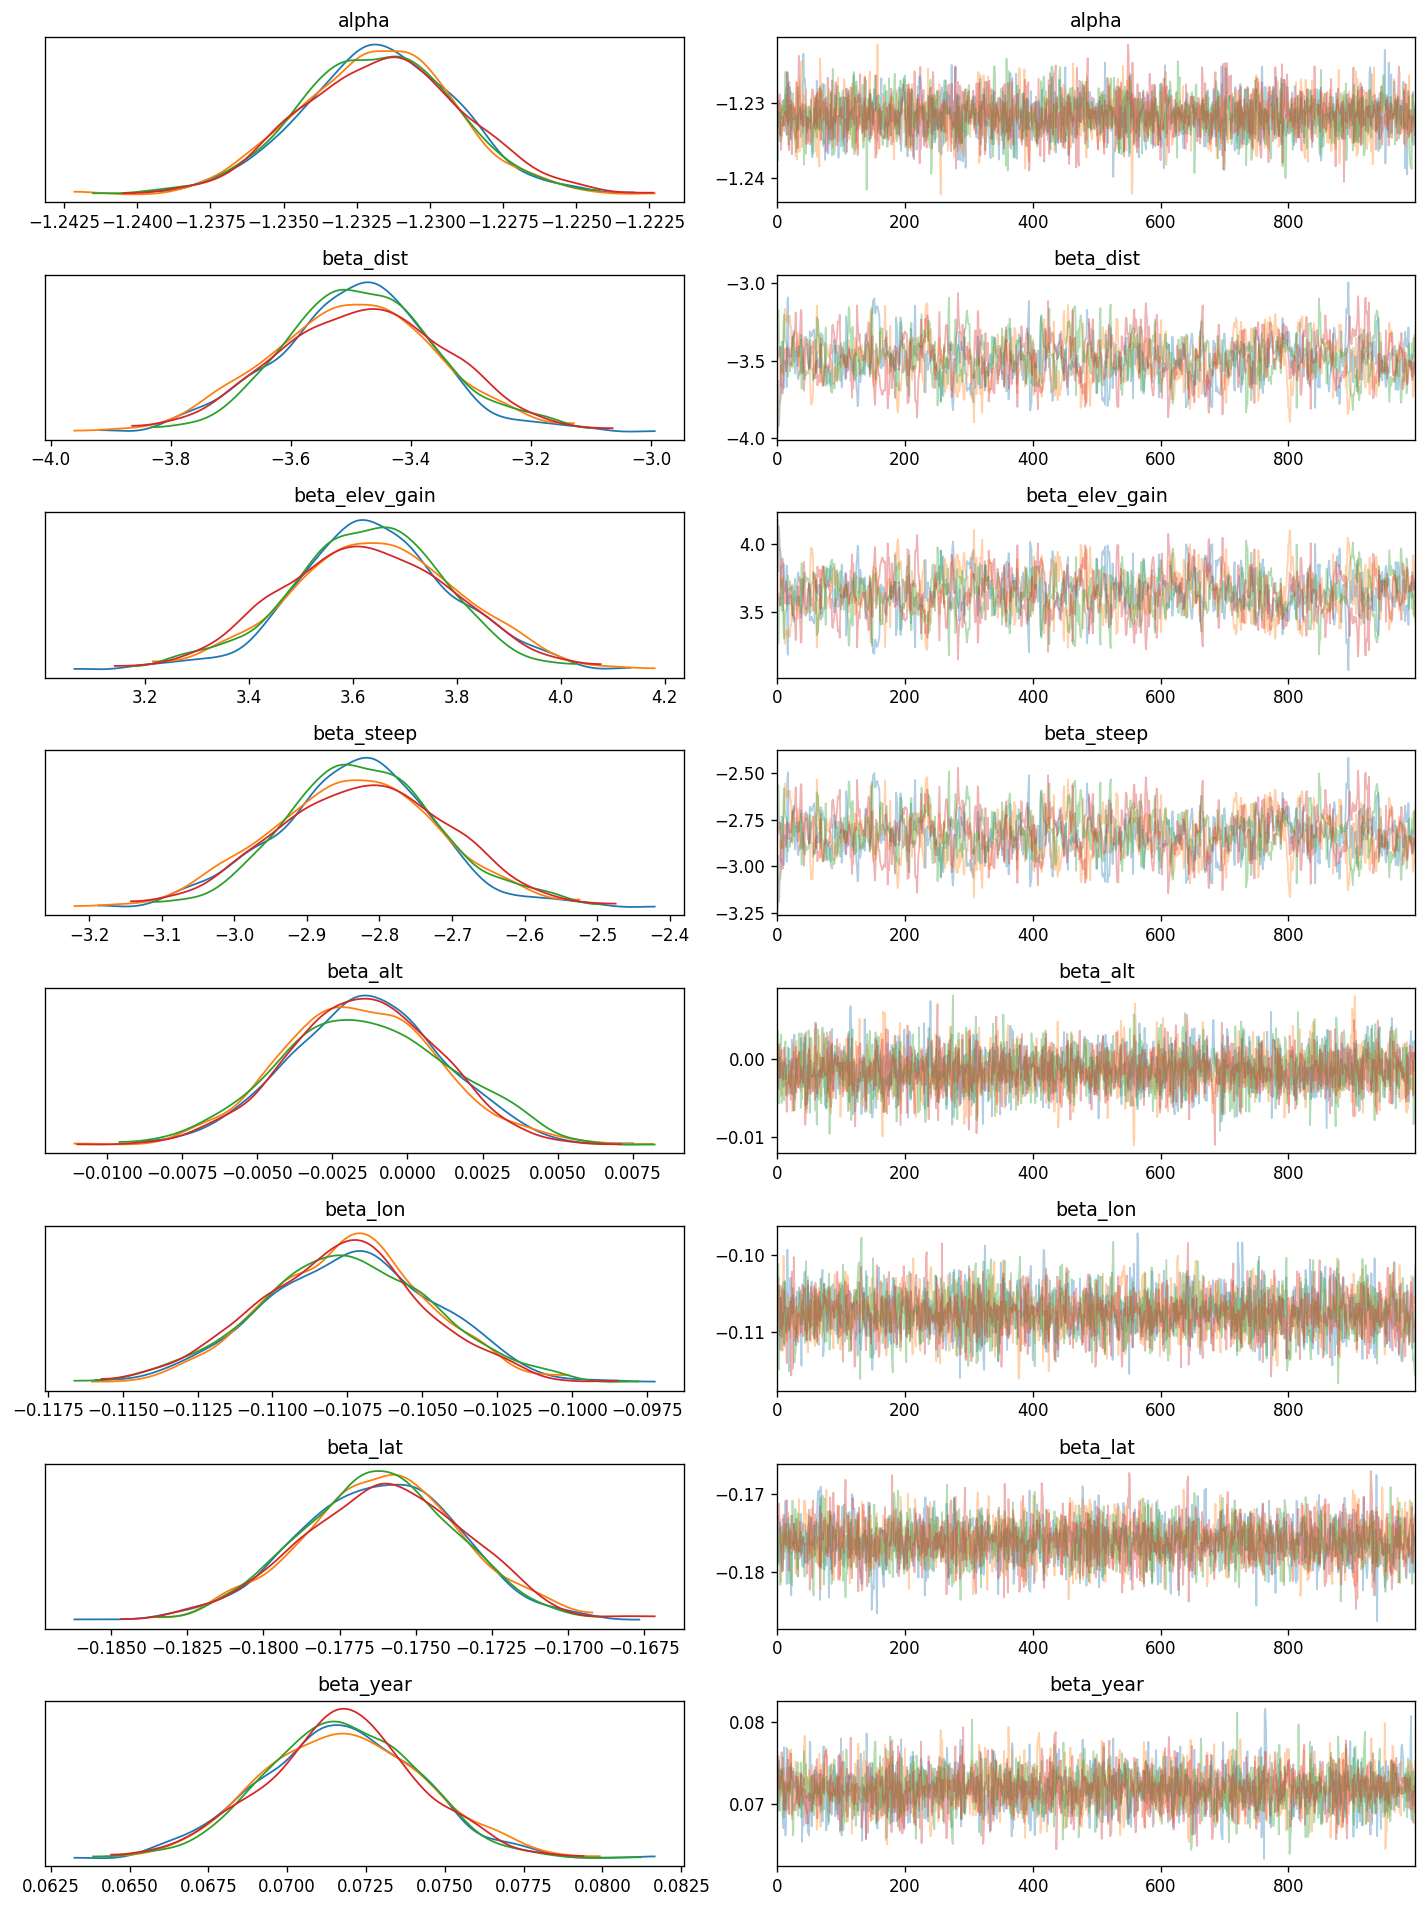

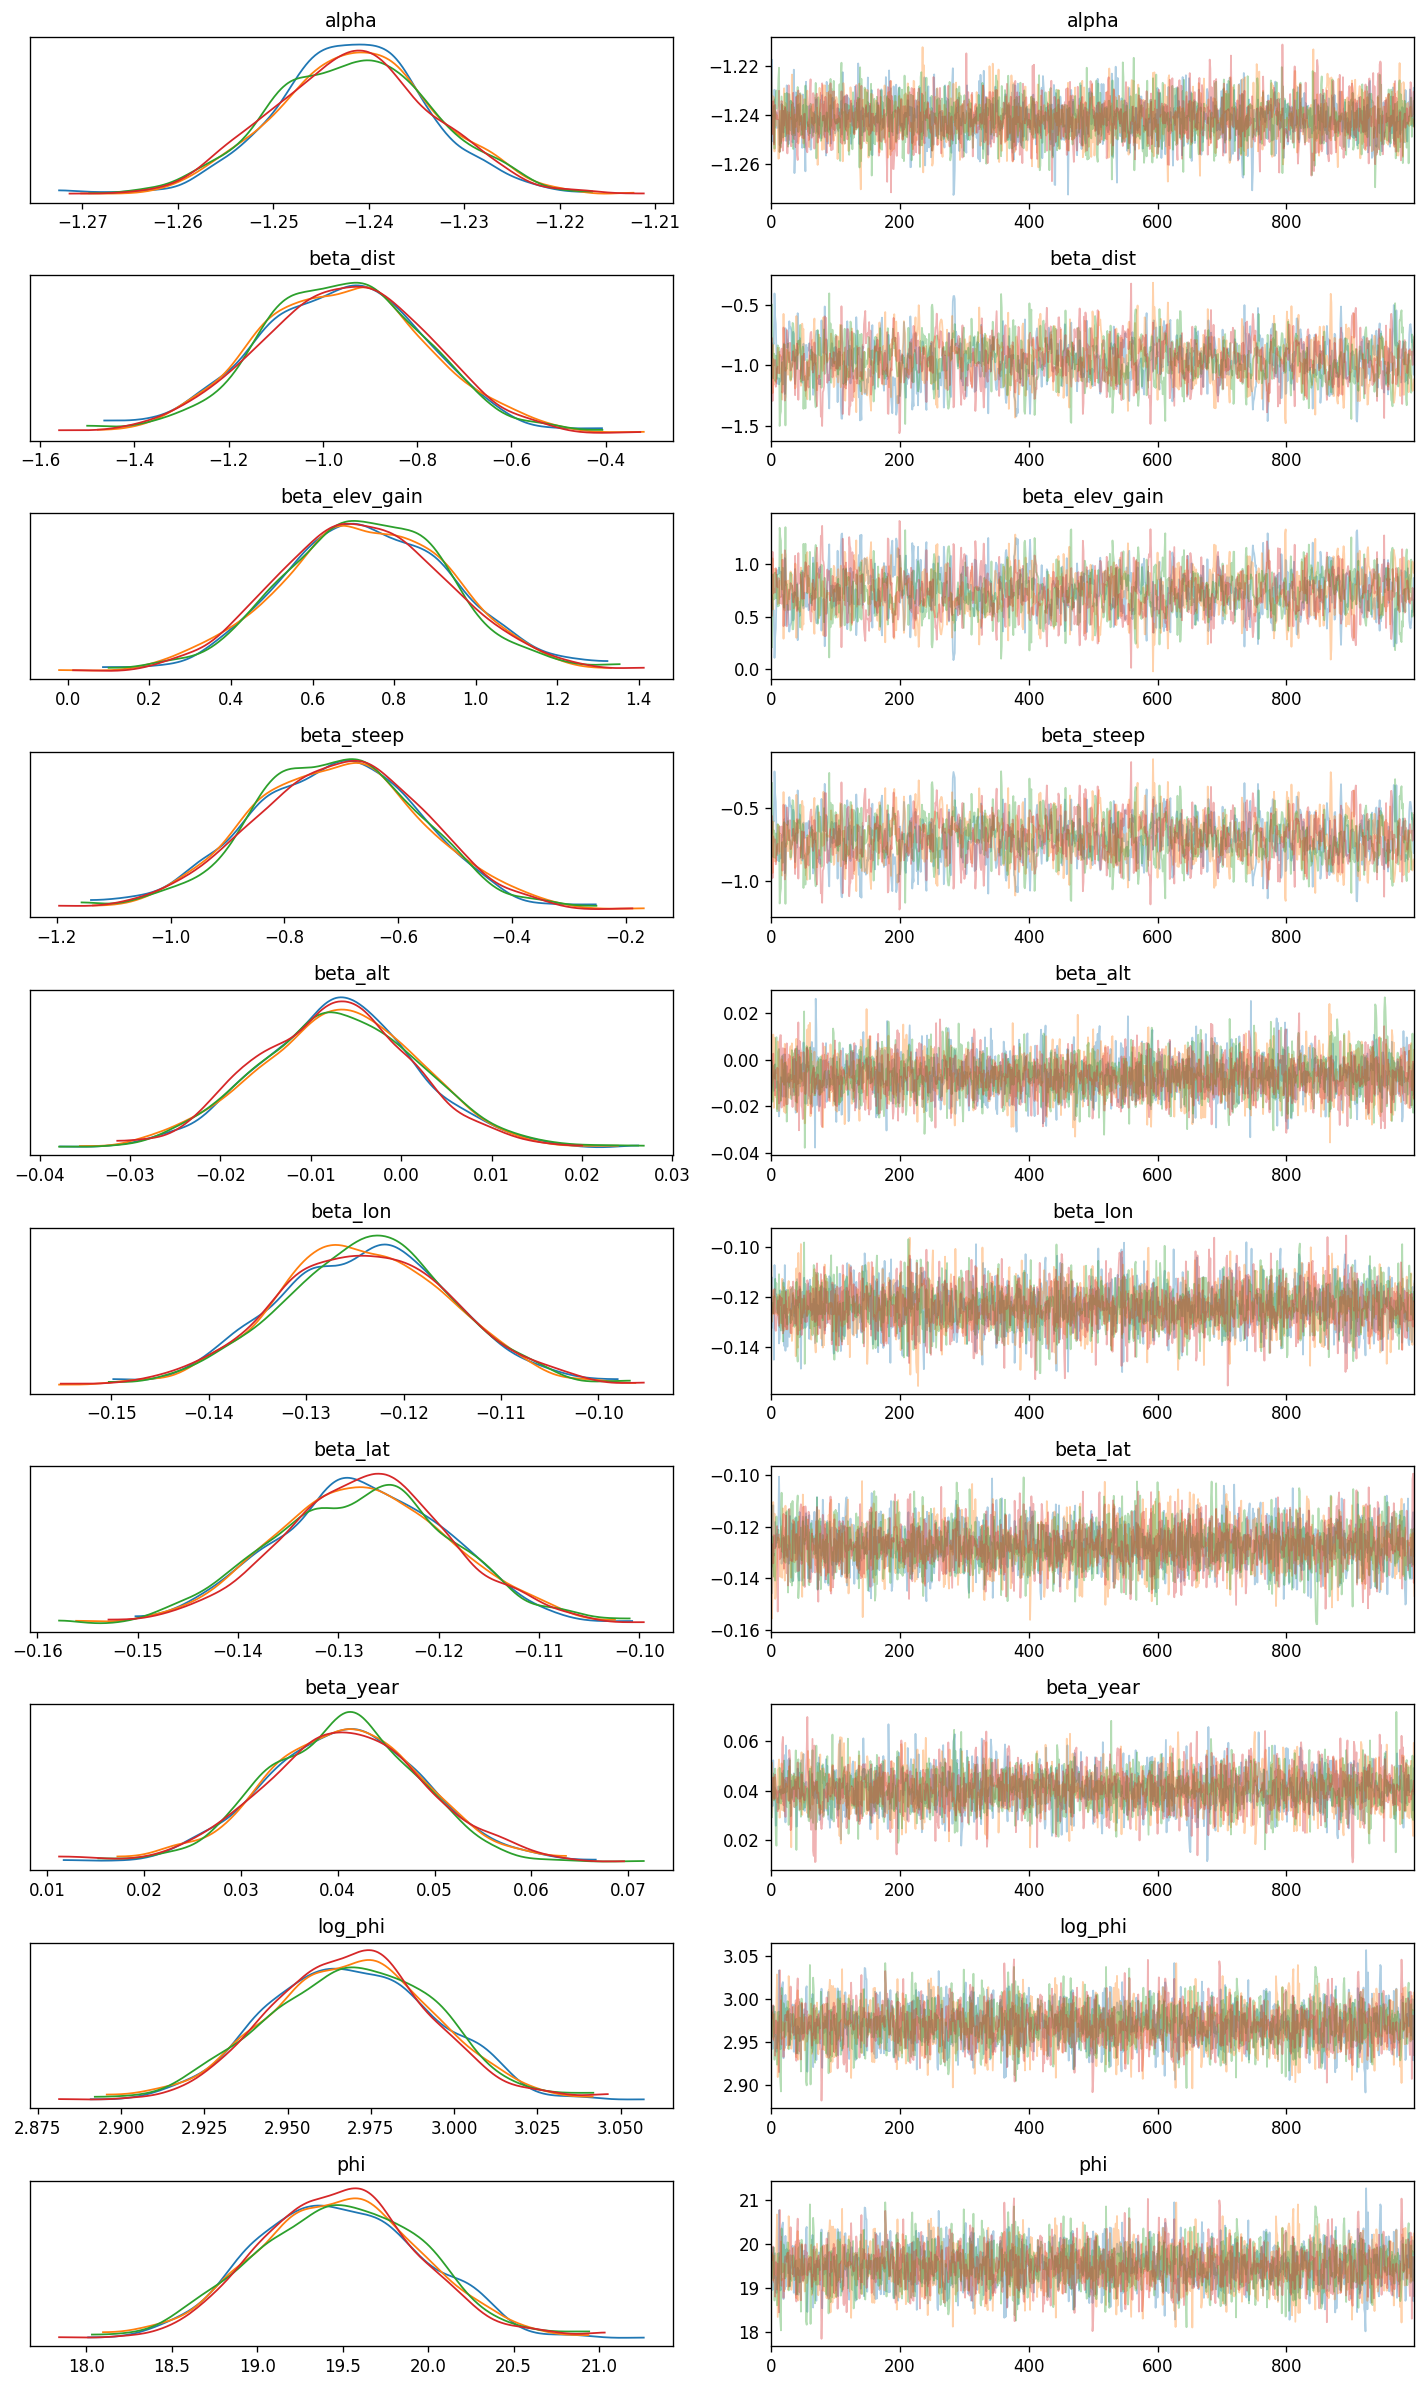

In [15]:
az.plot_trace(idata_binomial, var_names=param_vars, compact=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_fp_03_binomial_trace.png", bbox_inches="tight")
plt.show()

az.plot_trace(idata_beta_binomial, var_names=vars_beta, compact=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_fp_04_beta_binomial_trace.png", bbox_inches="tight")
plt.show()

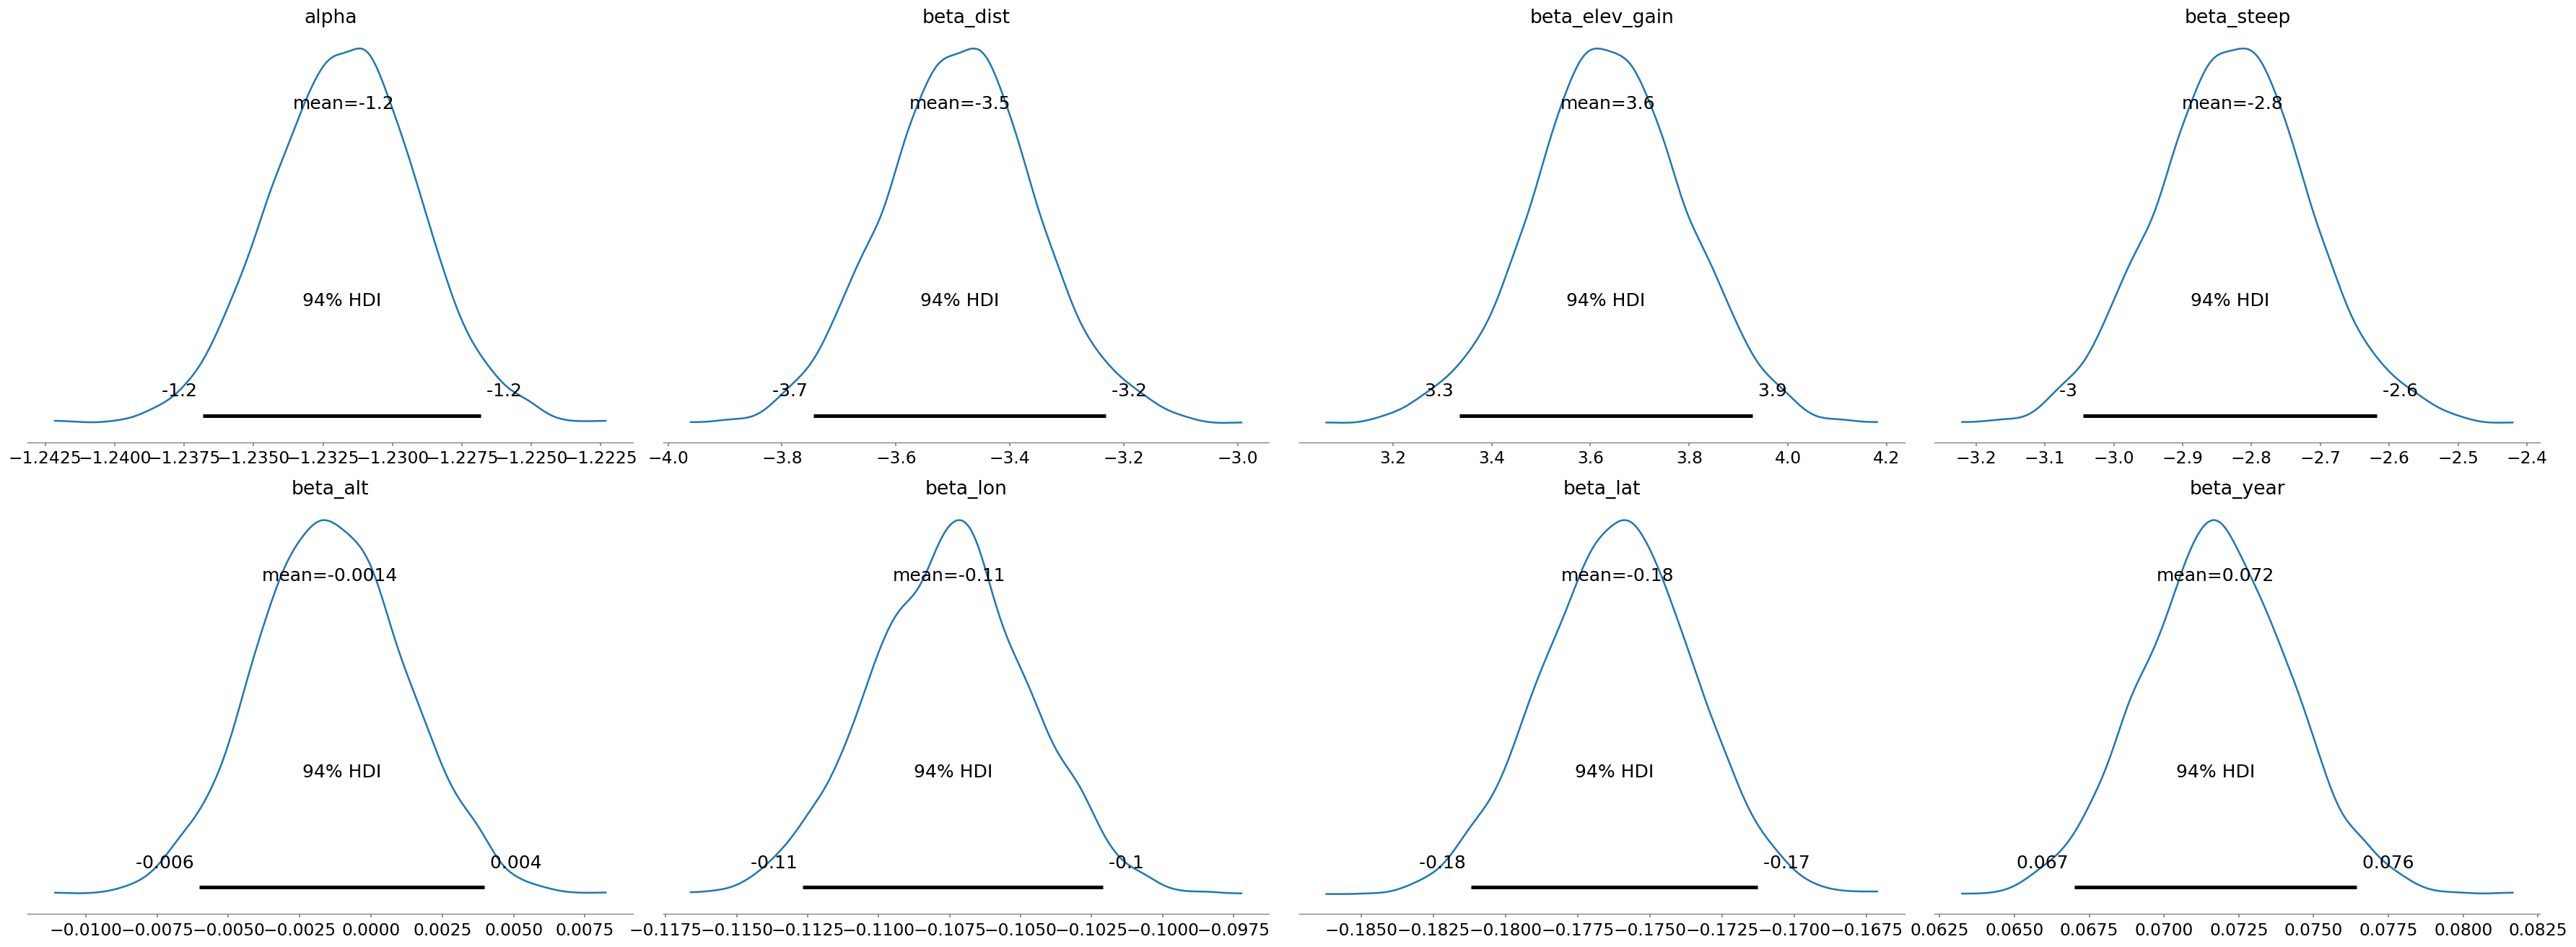

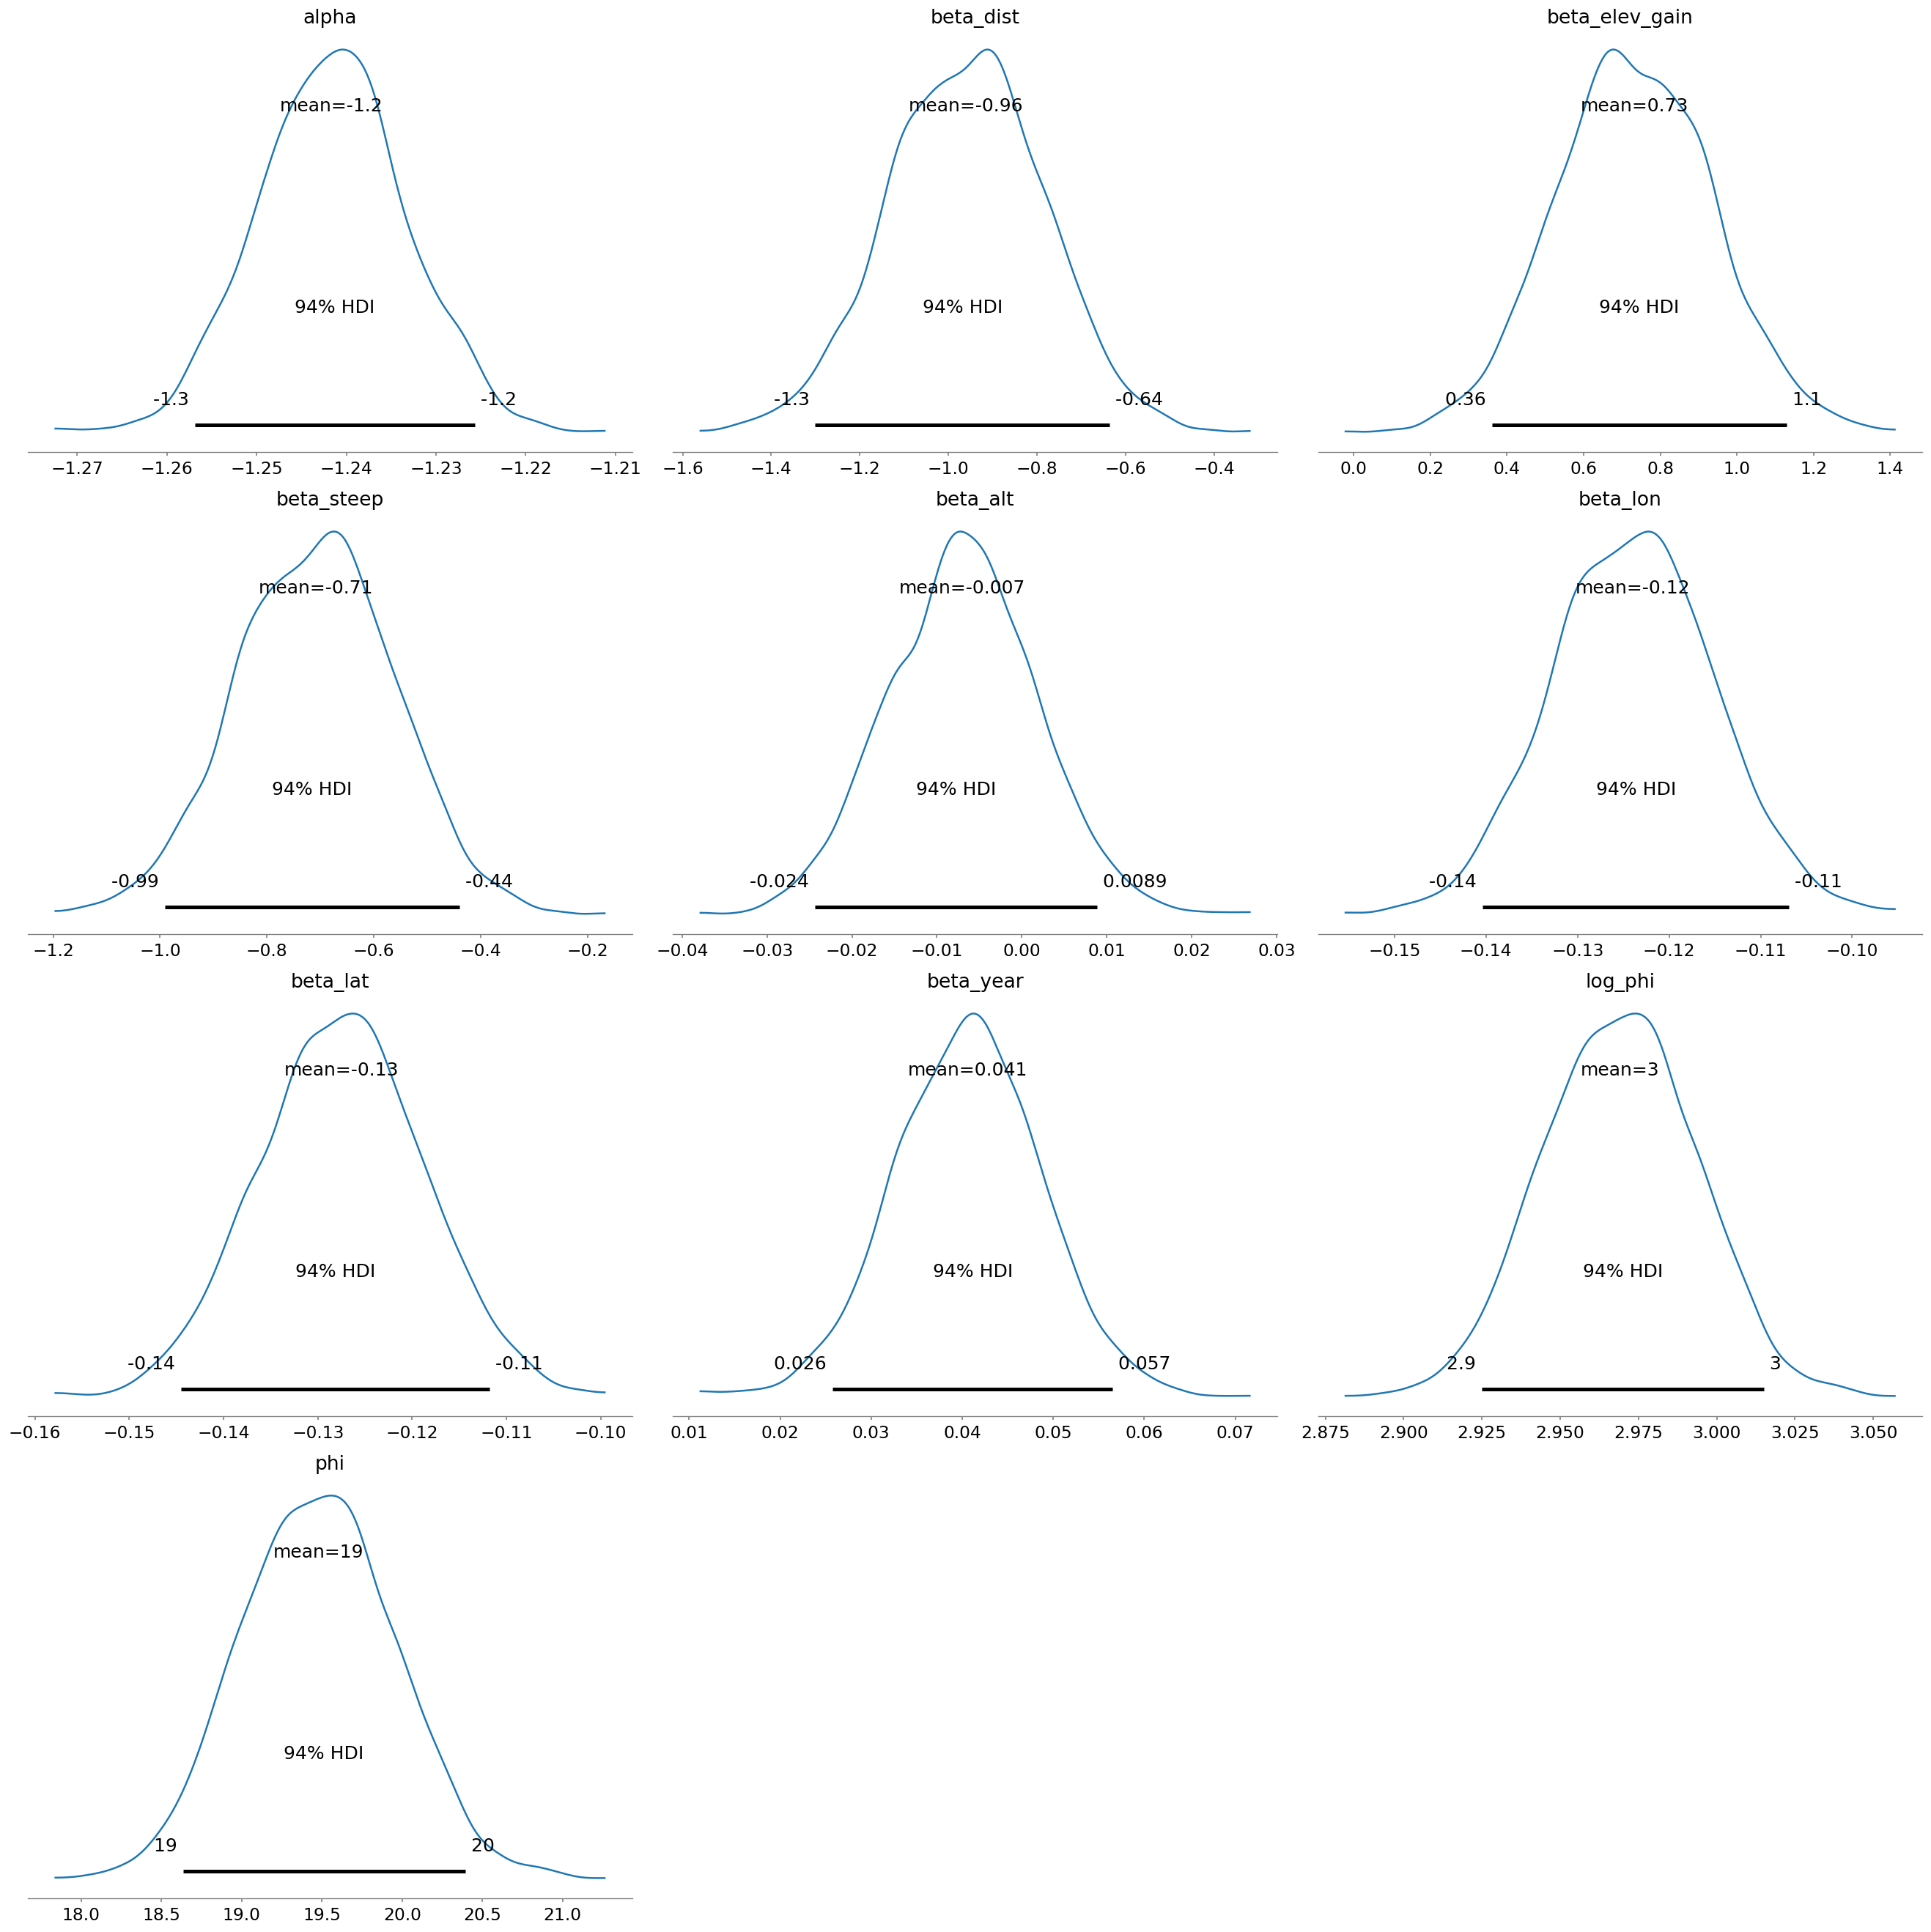

In [16]:
az.plot_posterior(idata_binomial, var_names=param_vars)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_fp_05_binomial_posteriors.png", bbox_inches="tight")
plt.show()

az.plot_posterior(idata_beta_binomial, var_names=vars_beta)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_fp_06_beta_binomial_posteriors.png", bbox_inches="tight")
plt.show()

In [17]:
def odds_ratio_table(fit, variables):
    rows = []
    for var in variables:
        draws = fit.stan_variable(var)
        or_draws = np.exp(draws)
        rows.append({
            "parameter": var,
            "median_OR": np.median(or_draws),
            "q05_OR": np.quantile(or_draws, 0.05),
            "q95_OR": np.quantile(or_draws, 0.95),
            "P_OR_gt_1": np.mean(or_draws > 1),
        })
    return pd.DataFrame(rows)

print("Odds ratios — Binomial model")
display(odds_ratio_table(fit_binomial, param_vars[1:]))

print("Odds ratios — Beta-Binomial model")
display(odds_ratio_table(fit_beta_binomial, param_vars[1:]))

Odds ratios — Binomial model


,parameter,median_OR,q05_OR,q95_OR,P_OR_gt_1
0,beta_dist,0.030599,0.024503,0.038336,0.0000
1,beta_elev_gain,37.844475,29.124814,49.001431,1.0000
2,beta_steep,0.059211,0.049159,0.071368,0.0000
3,beta_alt,0.998497,0.994257,1.003020,0.2905
4,beta_lon,0.898093,0.893798,0.902263,0.0000
5,beta_lat,0.838547,0.834774,0.842077,0.0000
6,beta_year,1.074338,1.069972,1.078803,1.0000


Odds ratios — Beta-Binomial model


,parameter,median_OR,q05_OR,q95_OR,P_OR_gt_1
0,beta_dist,0.384237,0.285261,0.509243,0.00000
1,beta_elev_gain,2.070200,1.492867,2.930030,0.99975
2,beta_steep,0.494104,0.384790,0.624852,0.00000
3,beta_alt,0.993013,0.978743,1.007487,0.21150
4,beta_lon,0.883465,0.870485,0.896613,0.00000
5,beta_lat,0.880290,0.867765,0.893090,0.00000
6,beta_year,1.041514,1.027718,1.055286,1.00000


### Results interpretation — regression coefficients and odds ratios

The Beta-Binomial model gives the more trustworthy coefficient interpretation because it accounts for overdispersion. In this model, a one-standard-deviation increase in `distance_log_std` multiplies the odds of a participant being female by approximately **0.38**. This is strong evidence that longer races have lower female participation, after controlling for the remaining predictors.

The `steepness_std` effect is also negative: the odds ratio is approximately **0.49**, meaning that steeper races are associated with lower female participation. The `altitude_std` effect is close to 1 and its interval includes 1, so there is no strong evidence for an independent altitude effect after controlling for distance, elevation gain, steepness, geography and year.

The `year_std` effect is positive in both models. In the Beta-Binomial model, the odds ratio is approximately **1.04** with posterior probability essentially equal to 1 that the effect is above 1. This supports the conclusion that female participation has increased over time.

The positive elevation-gain coefficient should be interpreted carefully. Because distance, elevation gain and steepness are strongly related, the coefficient describes the partial effect of elevation gain while holding distance and steepness fixed. It should not be read as a simple statement that harder races always attract more women.

## 7.11 Posterior predictive checks

The most important posterior predictive checks for this problem are not only raw counts, but also:

1. total number of women across races;
2. weighted female share: $\sum Y_i / \sum N_i$;
3. unweighted mean female share: average of $Y_i/N_i$;
4. female share by race category;
5. tail behaviour: whether the model generates enough races with very low/high female participation.

In [18]:
def posterior_rep_matrix(fit, variable="n_women_rep"):
    arr = fit.stan_variable(variable)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D array for {variable}, got shape {arr.shape}")
    return arr

rep_binom = posterior_rep_matrix(fit_binomial)
rep_beta = posterior_rep_matrix(fit_beta_binomial)

obs_women = df_fit["n_women"].to_numpy()
obs_participants = df_fit["n_participants"].to_numpy()
obs_share = obs_women / obs_participants

print(rep_binom.shape, rep_beta.shape)

(4000, 5000) (4000, 5000)


In [19]:
def ppc_summary_table(rep, label):
    total_women_rep = rep.sum(axis=1)
    weighted_share_rep = rep.sum(axis=1) / obs_participants.sum()
    unweighted_share_rep = (rep / obs_participants[None, :]).mean(axis=1)

    return pd.DataFrame({
        "model": [label, label, label],
        "statistic": ["total women", "weighted female share", "unweighted mean female share"],
        "observed": [obs_women.sum(), obs_women.sum() / obs_participants.sum(), obs_share.mean()],
        "posterior_mean": [total_women_rep.mean(), weighted_share_rep.mean(), unweighted_share_rep.mean()],
        "q05": [np.quantile(total_women_rep, 0.05), np.quantile(weighted_share_rep, 0.05), np.quantile(unweighted_share_rep, 0.05)],
        "q95": [np.quantile(total_women_rep, 0.95), np.quantile(weighted_share_rep, 0.95), np.quantile(unweighted_share_rep, 0.95)],
    })

ppc_table = pd.concat([
    ppc_summary_table(rep_binom, "Binomial"),
    ppc_summary_table(rep_beta, "Beta-Binomial"),
], ignore_index=True)

ppc_table

,model,statistic,observed,posterior_mean,q05,q95
0,Binomial,total women,220594.000000,220590.063000,219663.000000,221526.050000
1,Binomial,weighted female share,0.241473,0.241469,0.240454,0.242493
2,Binomial,unweighted mean female share,0.228253,0.233414,0.231732,0.235066
3,Beta-Binomial,total women,220594.000000,216991.307000,212952.800000,221050.150000
4,Beta-Binomial,weighted female share,0.241473,0.237529,0.233109,0.241972
5,Beta-Binomial,unweighted mean female share,0.228253,0.230174,0.226881,0.233753


### Results interpretation — posterior predictive checks

The Binomial model matches the total number of women and the weighted female share almost exactly, but this is misleading. Its posterior predictive intervals are extremely narrow because the plain Binomial likelihood assumes too little variability once `n_participants` and `p_i` are known.

The Beta-Binomial model produces wider and more realistic posterior predictive intervals. Its weighted female share posterior mean is slightly lower than observed, but the observed value is still close to the upper part of the posterior predictive interval. For the unweighted mean female share, the observed value is well covered by the Beta-Binomial posterior predictive interval.

This suggests that the Beta-Binomial model captures the main structure of the data while acknowledging extra race-level heterogeneity. In contrast, the Binomial model is too confident and underestimates the dispersion in participation rates across races.

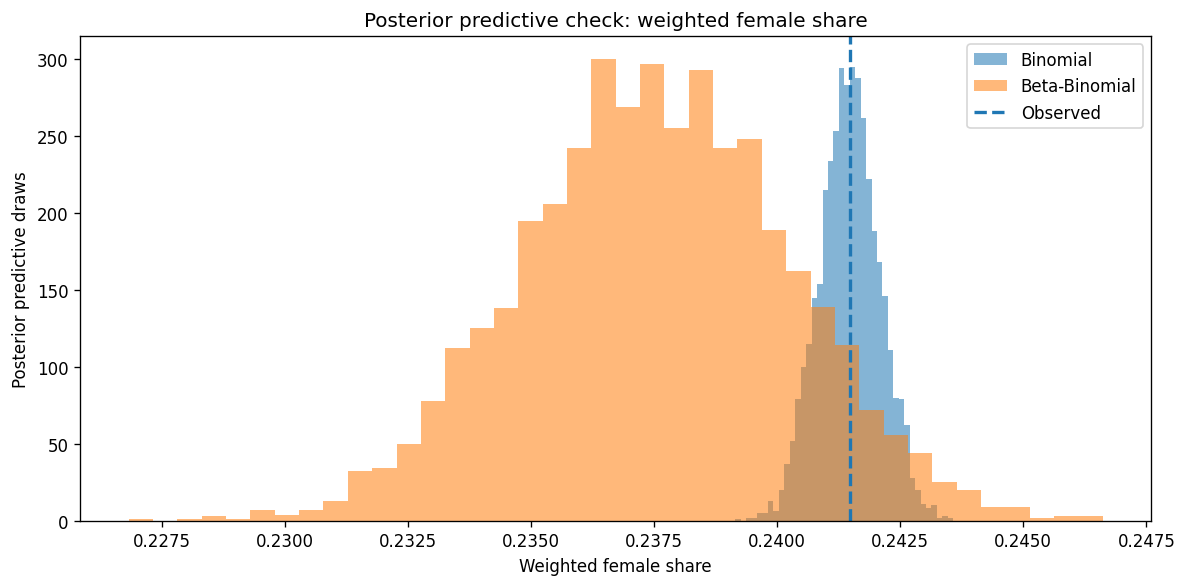

In [20]:
def plot_ppc_weighted_share(rep_binom, rep_beta):
    ws_binom = rep_binom.sum(axis=1) / obs_participants.sum()
    ws_beta = rep_beta.sum(axis=1) / obs_participants.sum()
    obs = obs_women.sum() / obs_participants.sum()

    plt.figure(figsize=(10, 5))
    plt.hist(ws_binom, bins=40, alpha=0.55, label="Binomial")
    plt.hist(ws_beta, bins=40, alpha=0.55, label="Beta-Binomial")
    plt.axvline(obs, linestyle="--", linewidth=2, label="Observed")
    plt.title("Posterior predictive check: weighted female share")
    plt.xlabel("Weighted female share")
    plt.ylabel("Posterior predictive draws")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig_fp_07_ppc_weighted_share.png", bbox_inches="tight")
    plt.show()

plot_ppc_weighted_share(rep_binom, rep_beta)

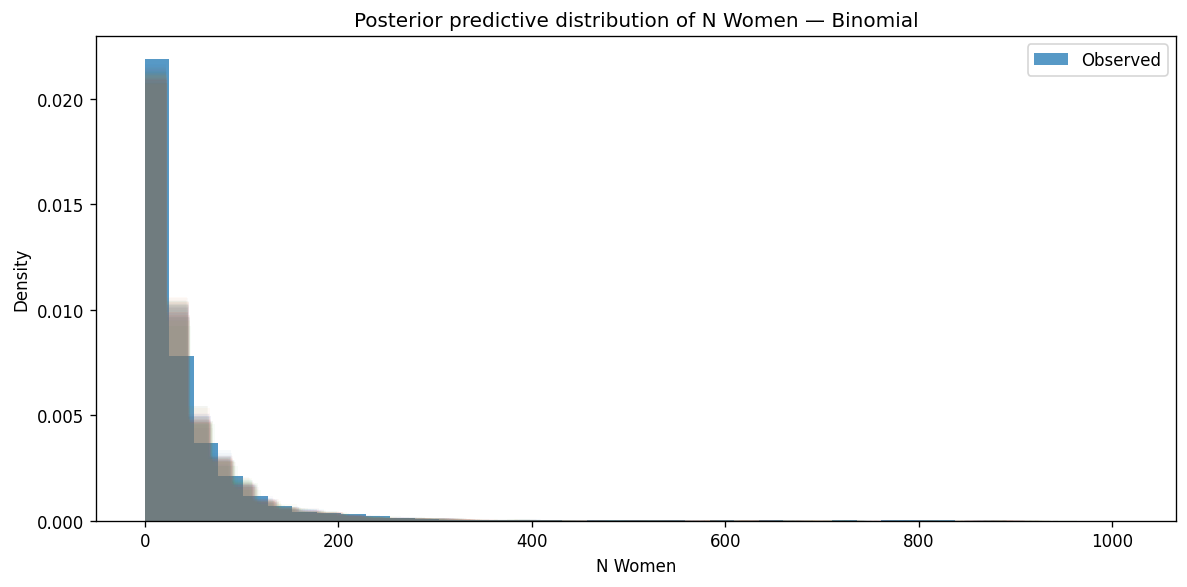

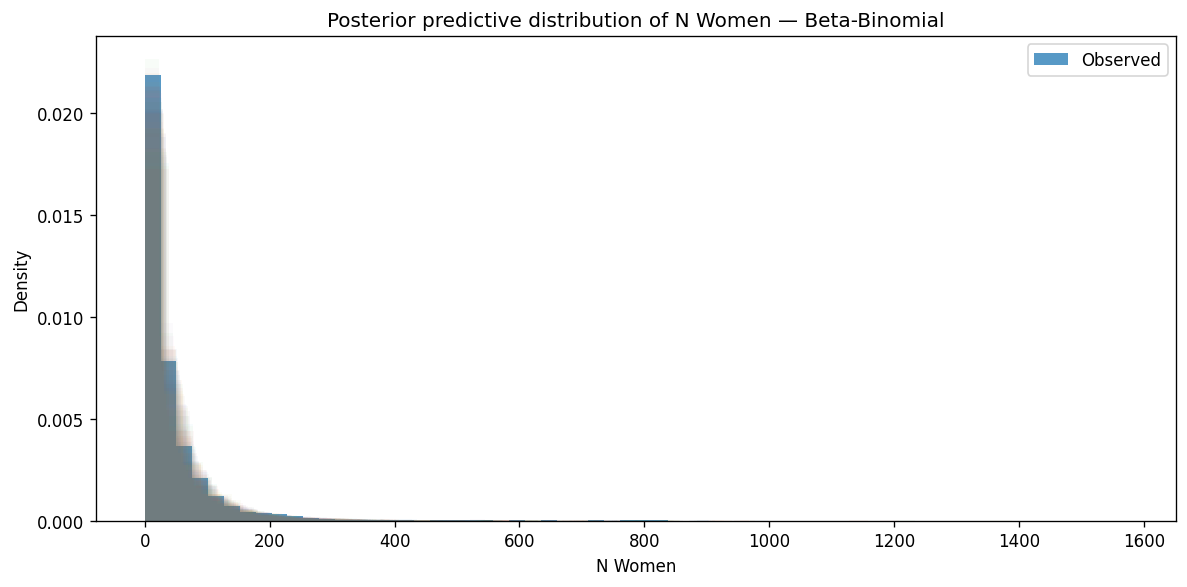

In [21]:
def plot_ppc_count_distribution(rep, label, filename):
    draw_ids = rng.choice(rep.shape[0], size=min(100, rep.shape[0]), replace=False)

    plt.figure(figsize=(10, 5))
    plt.hist(obs_women, bins=40, density=True, alpha=0.75, label="Observed")
    for d in draw_ids[:40]:
        plt.hist(rep[d], bins=40, density=True, alpha=0.03)
    plt.title(f"Posterior predictive distribution of N Women — {label}")
    plt.xlabel("N Women")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, bbox_inches="tight")
    plt.show()

plot_ppc_count_distribution(rep_binom, "Binomial", "fig_fp_08_ppc_counts_binomial.png")
plot_ppc_count_distribution(rep_beta, "Beta-Binomial", "fig_fp_09_ppc_counts_beta_binomial.png")

In [22]:
def category_ppc(rep, label):
    rows = []
    for cat in sorted(df_fit["Race Category"].unique()):
        mask = (df_fit["Race Category"].to_numpy() == cat)
        obs_cat = obs_women[mask].sum() / obs_participants[mask].sum()
        rep_cat = rep[:, mask].sum(axis=1) / obs_participants[mask].sum()
        rows.append({
            "model": label,
            "Race Category": cat,
            "observed": obs_cat,
            "posterior_mean": rep_cat.mean(),
            "q05": np.quantile(rep_cat, 0.05),
            "q95": np.quantile(rep_cat, 0.95),
        })
    return pd.DataFrame(rows)

cat_ppc = pd.concat([
    category_ppc(rep_binom, "Binomial"),
    category_ppc(rep_beta, "Beta-Binomial"),
], ignore_index=True)
cat_ppc

,model,Race Category,observed,posterior_mean,q05,q95
0,Binomial,100K,0.170667,0.165271,0.163382,0.167150
1,Binomial,100M,0.135230,0.137916,0.135335,0.140503
2,Binomial,20K,0.314729,0.311334,0.309650,0.313066
3,Binomial,50K,0.217407,0.222218,0.220896,0.223528
4,Beta-Binomial,100K,0.170667,0.167381,0.157493,0.177426
5,Beta-Binomial,100M,0.135230,0.143484,0.130347,0.157391
6,Beta-Binomial,20K,0.314729,0.300400,0.292694,0.308254
7,Beta-Binomial,50K,0.217407,0.220950,0.215147,0.226774


### Results interpretation — posterior predictive checks by race category

The category-level PPC confirms the exploratory pattern: female participation is highest in shorter races and lowest in ultra-long races. The Beta-Binomial model gives substantially wider category-level uncertainty intervals than the Binomial model, which is more realistic for heterogeneous race-level data.

For `100M`, the observed weighted share is approximately **13.5%**, while the Beta-Binomial posterior predictive interval covers this value. For `100K` and `50K`, the model also gives reasonable category-level predictions. The largest visible discrepancy is for `20K`, where the Beta-Binomial model tends to underpredict the weighted female share. This suggests that adding explicit race-category effects or a hierarchical category structure could improve the model.

Overall, the model captures the main monotonic relationship between distance category and female participation, but category-specific structure remains only partially explained by the continuous predictors.

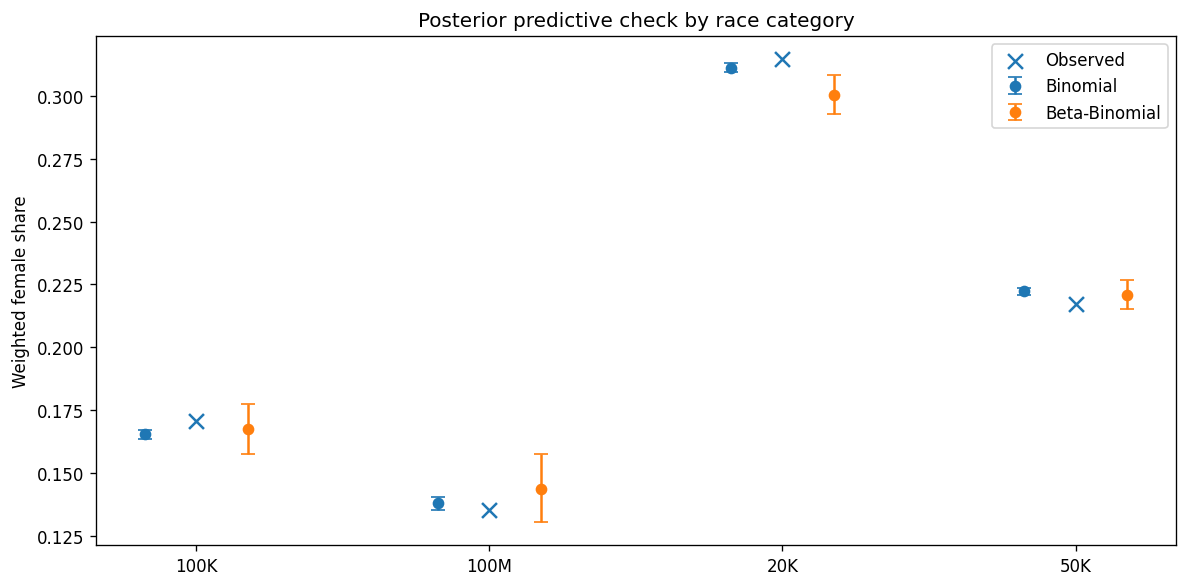

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

x_labels = sorted(df_fit["Race Category"].unique())
x = np.arange(len(x_labels))
width = 0.35

for j, model_name in enumerate(["Binomial", "Beta-Binomial"]):
    tmp = cat_ppc[cat_ppc["model"] == model_name].set_index("Race Category").loc[x_labels]
    offset = (j - 0.5) * width
    ax.errorbar(
        x + offset,
        tmp["posterior_mean"],
        yerr=[tmp["posterior_mean"] - tmp["q05"], tmp["q95"] - tmp["posterior_mean"]],
        fmt="o",
        capsize=4,
        label=model_name,
    )

obs_tmp = cat_ppc[cat_ppc["model"] == "Binomial"].set_index("Race Category").loc[x_labels]
ax.scatter(x, obs_tmp["observed"], marker="x", s=80, label="Observed")
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylabel("Weighted female share")
ax.set_title("Posterior predictive check by race category")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_fp_10_ppc_by_category.png", bbox_inches="tight")
plt.show()

## 7.12 Model comparison: LOO and WAIC

Both models use the same response and the same observations:

$$
Y_i = \text{N Women}_i
$$

Therefore, their log-likelihoods are directly comparable.

The comparison focuses on:

- **ELPD LOO**: higher is better;
- **WAIC**: higher ELPD is better;
- **Pareto-k diagnostics**: values above 0.7 indicate potentially unreliable LOO approximation.

Expected behaviour:

- If the Binomial model is too strict and underestimates variability, the Beta-Binomial model should win.
- If the data do not show strong overdispersion, the Binomial model may be sufficient.

In [24]:
loo_binomial = az.loo(idata_binomial, pointwise=True)
loo_beta_binomial = az.loo(idata_beta_binomial, pointwise=True)

waic_binomial = az.waic(idata_binomial, pointwise=True)
waic_beta_binomial = az.waic(idata_beta_binomial, pointwise=True)

print("LOO — Binomial")
print(loo_binomial)
print("\nLOO — Beta-Binomial")
print(loo_beta_binomial)

print("\nWAIC — Binomial")
print(waic_binomial)
print("\nWAIC — Beta-Binomial")
print(waic_beta_binomial)

LOO — Binomial
Computed from 4000 posterior samples and 5000 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -36293.98   898.70
p_loo      196.81        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     4994   99.9%
   (0.70, 1]   (bad)         5    0.1%
   (1, Inf)   (very bad)    1    0.0%


LOO — Beta-Binomial
Computed from 4000 posterior samples and 5000 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -18565.48    96.34
p_loo        8.94        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     5000  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%


WAIC — Binomial
Computed from 4000 posterior samples and 5000 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -36296.09   899.35
p_waic      198.92 

In [25]:
compare_loo = az.compare(
    {"Binomial": idata_binomial, "Beta-Binomial": idata_beta_binomial},
    ic="loo",
)
compare_waic = az.compare(
    {"Binomial": idata_binomial, "Beta-Binomial": idata_beta_binomial},
    ic="waic",
)

print("LOO comparison:")
display(compare_loo)

print("WAIC comparison:")
display(compare_waic)

LOO comparison:


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Beta-Binomial,0,-18565.480088,8.944712,0.000000,0.992971,96.337995,0.000000,False,log
Binomial,1,-36293.981847,196.809052,17728.501759,0.007029,898.701260,838.820611,True,log


WAIC comparison:


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Beta-Binomial,0,-18565.469982,8.934605,0.000000,0.99297,96.338004,0.000000,False,log
Binomial,1,-36296.088123,198.915327,17730.618141,0.00703,899.346783,839.495755,True,log


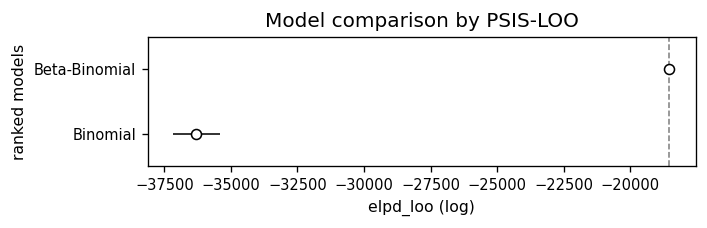

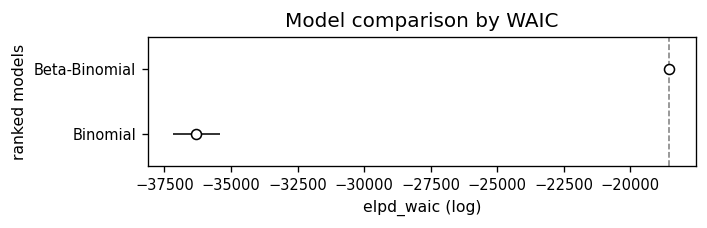

In [26]:
az.plot_compare(compare_loo)
plt.title("Model comparison by PSIS-LOO")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_fp_11_loo_comparison.png", bbox_inches="tight")
plt.show()

az.plot_compare(compare_waic)
plt.title("Model comparison by WAIC")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_fp_12_waic_comparison.png", bbox_inches="tight")
plt.show()

In [27]:
def pareto_k_summary(loo_obj, label):
    k = np.asarray(loo_obj.pareto_k)
    return pd.Series({
        "model": label,
        "max_k": k.max(),
        "mean_k": k.mean(),
        "n_k_gt_0_7": int((k > 0.7).sum()),
        "n_k_gt_1_0": int((k > 1.0).sum()),
    })

pareto_summary = pd.DataFrame([
    pareto_k_summary(loo_binomial, "Binomial"),
    pareto_k_summary(loo_beta_binomial, "Beta-Binomial"),
])
pareto_summary

,model,max_k,mean_k,n_k_gt_0_7,n_k_gt_1_0
0,Binomial,1.025691,-0.032512,6,1
1,Beta-Binomial,0.172526,-0.059584,0,0


### Results interpretation — model comparison

The model comparison gives a clear result: the **Beta-Binomial model strongly outperforms the Binomial model**. The Beta-Binomial model has much higher expected log predictive density, with `elpd_loo ≈ -18,565`, compared with `elpd_loo ≈ -36,294` for the Binomial model. The LOO model weight is approximately **0.993** for Beta-Binomial and only **0.007** for Binomial.

WAIC leads to the same conclusion. The Beta-Binomial model also has much better diagnostic behaviour: all Pareto-k values are below **0.7**, while the Binomial model has several problematic observations and one very bad Pareto-k value above **1.0**.

This is strong evidence that female participation data are overdispersed relative to a simple Binomial model. In practical terms, races with similar distance, elevation, location and year can still have substantially different female participation rates. The Beta-Binomial likelihood is therefore the preferred model for this task.

## 7.13 Final conclusions

The goal of this notebook was to model the number of women participating in UTMB races using course, geographic and temporal predictors. Because the target is a count bounded by the total number of participants, the model was formulated as:

```text
n_women_i | n_participants_i, p_i
```

rather than as an unconstrained regression problem. Two likelihoods were compared:

1. **Binomial logistic regression** — a baseline model assuming that, conditional on predictors, all race-level variation is explained by Binomial sampling noise.
2. **Beta-Binomial logistic regression** — an overdispersed model allowing additional race-to-race variability in female participation rates.

The empirical analysis shows that female participation depends strongly on race distance and difficulty. The observed weighted female share decreases from approximately **31.0%** in `20K` races to approximately **13.6%** in `100M` races. The posterior coefficients confirm this pattern: in the preferred Beta-Binomial model, both distance and steepness have negative effects on the odds of female participation.

The year effect is positive, indicating that female participation has increased over time. This is one of the most important substantive findings of the notebook. The effect is not merely descriptive: it remains positive after controlling for distance, elevation gain, steepness, altitude, longitude and latitude.

The comparison of likelihoods is decisive. The Beta-Binomial model strongly outperforms the Binomial model according to both LOO and WAIC. It also has much better Pareto-k diagnostics and more realistic posterior predictive uncertainty. This means that the simple Binomial likelihood is too restrictive for this dataset, because UTMB races differ in ways that are not fully captured by the available predictors.

The preferred final model is therefore the **Beta-Binomial logistic regression model**. It should be used for reporting and interpretation, while the Binomial model should be treated mainly as a baseline demonstrating why overdispersion matters.

### Main findings

- Female participation is highest in shorter races and lowest in the longest ultra-distance races.
- Longer distance is associated with lower odds of female participation.
- Greater steepness is associated with lower odds of female participation.
- Elevation gain has a positive partial effect after controlling for distance and steepness, but this should be interpreted cautiously because the terrain variables are correlated.
- Altitude has no strong independent effect in the fitted model.
- Female participation increases over time.
- The Beta-Binomial likelihood is clearly preferable to the simple Binomial likelihood.

### Suggested model improvement

A natural next step would be to add **race-category effects** or a **hierarchical structure by race category/country/year**. The current model captures the main trends, but the PPC by category suggests that `20K` races have additional structure that is not fully explained by the continuous predictors alone.

In [28]:
print("Notebook finished. Key generated files:")
print("  utmb_female_participation_processed.csv")
print("  model7_female_binomial.stan")
print("  model8_female_beta_binomial.stan")
print(f"  figures in: {FIG_DIR}")

Notebook finished. Key generated files:
  utmb_female_participation_processed.csv
  model7_female_binomial.stan
  model8_female_beta_binomial.stan
  figures in: figures_female_participation
